In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

import torch

from xgboost import XGBClassifier
from pandas.api.types import CategoricalDtype

from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

! pip install fairlearn
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import true_positive_rate, true_negative_rate, false_positive_rate, false_negative_rate, selection_rate

from fairlearn.metrics import MetricFrame

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

#### 데이터, 모델 불러오기

In [4]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

In [5]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [6]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [7]:
import joblib
# XGBoost
model_data = joblib.load("Model/xgb_package2.pkl")
model = model_data['model']
fixed_params = model_data['fixed_params']
del fixed_params['early_stopping_rounds'] # Fairlearn에서는 early stopping 끄기 (여러 개의 모델을 만들어서 가중평균하는 방식이므로..)
best_params = model_data['best_params']
threshold = model_data['threshold']

y_pred = joblib.load("Model/xgb_pred2.pkl")

/usr/lib/python3.12/pickle.py:1760: UserWarning: [05:20:42] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [8]:
for col in data[x_cols].columns:
    if col in cat_cols:
        data[col] = data[col].astype(str).astype('category')
    else:
        data[col] = data[col].astype(np.float64)

train = data[data['period'].isin([2017, 2018])]
val = data[data['period'] == 2018]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_val = val[x_cols]
y_val = val[target]
x_test = test[x_cols]
y_test = test[target]

In [9]:
# 불균형 데이터 가중치 계산
spw = (y_train == 0).sum() / (y_train == 1).sum()
device = "cuda" if torch.cuda.is_available() else "cpu"

#### 민감변수 처리

In [10]:
def get_sens_features(var_name, sens_config, x_train = x_train, x_val = x_val, x_test = x_test):
    """특정 변수에 대해 민감변수 속성 생성"""

    if var_name == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name == 'age':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() in ['c_gi', 'c_ie_t']:
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        var_name = var_name.upper()
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name.lower() == 'c_h':
        train_sens = x_train['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        val_sens = x_val['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        test_sens = x_test['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])

    if var_name.lower() == 'age_gender':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        age_train_bin = pd.cut(x_train['age'], bins = bins, labels = labels)
        age_val_bin = pd.cut(x_val['age'], bins = bins, labels = labels)
        age_test_bin = pd.cut(x_test['age'], bins = bins, labels = labels)
        train_sens = pd.DataFrame({'gen_age': x_train['gender'].astype(str) + "_" + age_train_bin.astype(str)})
        val_sens = pd.DataFrame({'gen_age': x_val['gender'].astype(str) + "_" + age_val_bin.astype(str)})
        test_sens = pd.DataFrame({'gen_age': x_test['gender'].astype(str) + "_" + age_test_bin.astype(str)})

    return train_sens, val_sens, test_sens

In [11]:
sens_config = {
    'age':{
        'bins' : [0, 19, 29, 39, 49, 59, 69, 100],
        'labels' : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    },
    'age_gender':{
        'bins' :  [0, 25, 40, 60, 100],
        'labels' : ['청년', '장년', '중년', '고령']
    },
    'c_gi':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' : ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']
    },
    'c_ie_t':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' :['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']
    },
    'c_h':{
        'c_h_map_inv' : {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}
    }
}

#### 모델링

목적식(Objective Function):

$$min_\theta Loss(y, \hat{y}) + \lambda \cdot Constraint(A, \hat{y})$$



- $Loss(y, \hat{y})$ : 기존의 분류 오차(ex. Logloss). 모델의 정확도를 결정
- $Constraint(A, \hat{y})$ : 공정성 페널티. 집단 A간의 지표 차이가 커질수록 값이 커지는 구조
    - 지표 : Equalized Odds로 설정
- $\lambda$ : 공성성을 얼마나 강력하게 강제할 것인지

In [71]:
def fit_base_model(x_train, x_test, y_train, y_test, x_test_sensitive, best_params, fixed_params, threshold):

    final_params = {**best_params, **fixed_params}

    # 모델 학습
    model = XGBClassifier(**final_params, enable_categorical = True)
    model.fit(x_train, y_train, verbose = False)

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return y_pred

In [72]:
def fairlearn_model(x_train, y_train, x_test, y_test,
                    x_train_sensitive, x_test_sensitive,
                    best_params, fixed_params, threshold,
                    epsilon = 0.05, n_iter = 30):

    # 제약 조건 설정
    eo_constraints = EqualizedOdds()

    # 베이스 모델 정의
    base_model = XGBClassifier(
        **best_params,
        **fixed_params,
        enable_categorical = True
    )

    # Mitigator 정의
    mitigator = ExponentiatedGradient(
        estimator = base_model,
        constraints = eo_constraints,
        eps = epsilon, # 공정성 허용 오차. 작을수록 더 강력하게 차별을 방지 but 정확도 희생
        max_iter = n_iter
    )

    # 재학습
    print("\n⚖️ Fairlearn 재학습 중...")
    mitigator.fit(x_train, y_train, sensitive_features = x_train_sensitive)

    # 예측
    y_pred_mit = mitigator.predict(x_test)
    y_prob_mit = mitigator._pmf_predict(x_test)[:, 1]

    aucpr = average_precision_score(y_test, y_prob_mit)
    f1 = f1_score(y_test, y_pred_mit)
    precision = precision_score(y_test, y_pred_mit)
    recall = recall_score(y_test, y_pred_mit)
    print("========================================")
    print("       [Fairlearn 모델 1차 학습 성능 결과]        ")
    print("========================================")
    print(f"F1-Score: {f1:.4f}")
    print(f"PR-AUC: {aucpr:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")

    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_mit,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method='between_groups'))

    return mitigator, y_pred_mit, y_prob_mit

In [73]:
# def threshold_tuning(mitigator, x_val, y_val, x_test, y_test,
#                      x_val_sensitive, x_test_sensitive):

#     # val 확률 (threshold 계산용) - weighted 방식으로 변경
#     y_val_prob = np.zeros(len(x_val))
#     for est, weight in zip(mitigator.predictors_, mitigator.weights_):
#         y_val_prob += weight * est.predict_proba(x_val)[:, 1]

#     # test 확률 (threshold 적용용) - weighted 방식으로 변경
#     y_prob_mit_weighted = np.zeros(len(x_test))
#     for est, weight in zip(mitigator.predictors_, mitigator.weights_):
#         y_prob_mit_weighted += weight * est.predict_proba(x_test)[:, 1]

#     y_val_pred = mitigator.predict(x_val)

#     metrics_dict = {'fpr': false_positive_rate, 'fnr': false_negative_rate}
#     mf_val = MetricFrame(metrics = metrics_dict, y_true = y_val, y_pred = y_val_pred, sensitive_features = x_val_sensitive)

#     target_fpr = mf_val.by_group['fpr'].mean()
#     target_fnr = mf_val.by_group['fnr'].mean()

#     thresholds = get_group_thresholds(y_val, y_val_prob, x_val_sensitive, target_fpr, target_fnr)
#     y_pred_post = apply_group_thresholds(y_prob_mit_weighted, x_test_sensitive, thresholds)

#     # 튜닝 전 FPR 격차
#     y_pred_orig = mitigator.predict(x_test)
#     mf_before = MetricFrame(metrics={'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_orig, sensitive_features = x_test_sensitive)
#     fpr_gap_before = mf_before.difference(method='between_groups')['fpr']

#     # 튜닝 후 FPR 격차
#     mf_after = MetricFrame(metrics={'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_post, sensitive_features = x_test_sensitive)
#     fpr_gap_after = mf_after.difference(method='between_groups')['fpr']

#     # 튜닝 후 더 나빠졌으면 원래 예측값 사용
#     if fpr_gap_after > fpr_gap_before + 0.01:
#         print(f"⚠️ 튜닝 후 FPR 격차가 더 벌어짐 ({fpr_gap_before:.4f} → {fpr_gap_after:.4f}), mitigator 원래 예측값으로 대체합니다.")
#         y_pred_post = y_pred_orig

#     f1 = f1_score(y_test, y_pred_post)
#     pr_auc = average_precision_score(y_test, y_prob_mit_weighted)
#     prec = precision_score(y_test, y_pred_post)
#     rec = recall_score(y_test, y_pred_post)

#     print("========================================")
#     print("       [최종 모델 전체 성능 결과]        ")
#     print("========================================")
#     print(f"F1-Score  : {f1:.4f}")
#     print(f"PR-AUC : {pr_auc:.4f}")
#     print(f"Recall    : {rec:.4f}")
#     print(f"Precision : {prec:.4f}")

#     metrics_final = {
#         'selection_rate': selection_rate,
#         'tpr': true_positive_rate,
#         'tnr': true_negative_rate,
#         'fpr': false_positive_rate,
#         'fnr': false_negative_rate
#     }

#     mf = MetricFrame(
#         metrics=metrics_final,
#         y_true=y_test,
#         y_pred=y_pred_post,
#         sensitive_features=x_test_sensitive
#     )

#     print("\n========================================")
#     print("       [최종 - 집단별 임계값]       ")
#     print("========================================")
#     for group, thr in thresholds.items():
#         print(f"Group {group}: {thr:.4f}")

#     print("\n========================================")
#     print("       [최종 - 연령대별 공정성 세부 지표]       ")
#     print("========================================")
#     print(mf.by_group)

#     print("\n========================================")
#     print("       [최종 - 집단 간 최대 격차 (Max Gap)]      ")
#     print("========================================")
#     print(mf.difference(method='between_groups'))

#     return thresholds, y_pred_post

# def apply_group_thresholds(y_prob_mit, x_train_sensitive, group_thresholds):
#     y_prob_mit = np.array(y_prob_mit)
#     x_train_sensitive = np.array(x_train_sensitive).flatten()

#     y_pred_post = np.zeros_like(y_prob_mit, dtype = int)
#     for group, thr in group_thresholds.items():
#         mask = (x_train_sensitive == group)
#         y_pred_post[mask] = (y_prob_mit[mask] >= thr).astype(int)
#     return y_pred_post


# def get_group_thresholds(y_true, y_prob, sensitive_features, target_fpr, target_fnr):
#     y_true = np.array(y_true)
#     y_prob = np.array(y_prob)
#     sensitive_features = np.array(sensitive_features).flatten()

#     group_thresholds = {}
#     groups = np.unique(sensitive_features)
#     ### 변경 (0605)
#     target_tpr = 1 - target_fnr
#     ###

#     plt.figure(figsize = (10, 6))

#     for group in groups:
#         # print(f"Group {group} Target FPR : {target_fpr}")
#         # print(f"Group {group} Target FNR : {target_fnr}")
#         mask = (sensitive_features == group)

#         if len(np.unique(y_prob[mask])) <= 2:
#             print(f"‼️{group} : 이미 최적의 공정한 상태이므로 추가 튜닝을 진행하지 않습니다.‼️")
#             group_thresholds[group] = 1
#             continue

#         fpr, tpr, thresholds = roc_curve(y_true[mask], y_prob[mask])
#         fnr = 1 - tpr

#         # print(f"Group {group} FPR array: {fpr[:5]}")
#         # print(f"Group {group} Thresholds array: {thresholds[:5]}")

#         thresholds[0] = max(y_prob[mask]) + 1e-9

#         ### 변경 (0605) - FPR 우선, TPR 허용 #######################
#         fpr_tolerance = 0.008
#         fpr_candidates = np.where(np.abs(fpr - target_fpr) <= fpr_tolerance)[0] # FPR 허용 오차 내 후보만 고려

#         if len(fpr_candidates) == 0:
#             idx = np.argmin(np.abs(fpr - target_fpr)) # 후보 없으면 기존 논리로
#         else:
#             idx = fpr_candidates[np.argmin(np.abs(tpr[fpr_candidates] - target_tpr))]
#         ####################################################

#         group_thresholds[group] = float(np.clip(group_thr, 0.0, 1.0))

#         plt.plot(fpr, tpr, label = f'Group {group} (Thr: {group_thr:.4f})')
#         plt.scatter(target_fpr, np.interp(target_fpr, fpr, tpr), marker='o')

#     plt.axvline(x = target_fpr, color = 'red', linestyle = '--', label = f'Target FPR ({target_fpr})')
#     plt.xlabel('False Positive Rate (FPR)')
#     plt.ylabel('True Positive Rate (TPR)')
#     plt.title(f'ROC Curves by Group (Target FPR = {target_fpr})')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     return group_thresholds

In [74]:
def threshold_tuning(mitigator, x_train, y_train, x_val, y_val, x_test, y_test,
                     x_train_sensitive, x_val_sensitive, x_test_sensitive):

    # train + val 합치기
    # x_trainval = pd.concat([x_train, x_val], axis=0).reset_index(drop=True)
    # y_trainval = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)
    # x_trainval_sensitive = pd.concat([pd.Series(x_train_sensitive.squeeze()),
    #                                    pd.Series(x_val_sensitive.squeeze())], axis=0).reset_index(drop=True)

    # val 확률 (threshold 계산용) - weighted 방식
    y_val_prob = np.zeros(len(x_val))
    for est, weight in zip(mitigator.predictors_, mitigator.weights_):
        y_val_prob += weight * est.predict_proba(x_val)[:, 1]

    # test 확률 (threshold 적용용) - weighted 방식
    y_prob_mit_weighted = np.zeros(len(x_test))
    for est, weight in zip(mitigator.predictors_, mitigator.weights_):
        y_prob_mit_weighted += weight * est.predict_proba(x_test)[:, 1]

    y_val_pred = mitigator.predict(x_val)

    metrics_dict = {'fpr': false_positive_rate, 'fnr': false_negative_rate}
    mf_val = MetricFrame(metrics = metrics_dict, y_true = y_val, y_pred = y_val_pred, sensitive_features = x_val_sensitive)

    # target: train+val 기준 FPR/FNR mean
    target_fpr = mf_val.by_group['fpr'].mean()
    target_fnr = mf_val.by_group['fnr'].mean()

    print(f"Target FPR: {target_fpr:.4f} (mean), Target FNR: {target_fnr:.4f} (mean)")

    thresholds = get_group_thresholds(y_val, y_val_prob, x_val_sensitive, target_fpr, target_fnr)
    y_pred_post = apply_group_thresholds(y_prob_mit_weighted, x_test_sensitive, thresholds)

    # 튜닝 전 FPR 격차
    y_pred_orig = mitigator.predict(x_test)
    mf_before = MetricFrame(metrics = {'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_orig, sensitive_features = x_test_sensitive)
    fpr_gap_before = mf_before.difference(method='between_groups')['fpr']

    # 튜닝 후 FPR 격차
    mf_after = MetricFrame(metrics = {'fpr': false_positive_rate}, y_true = y_test, y_pred = y_pred_post, sensitive_features = x_test_sensitive)
    fpr_gap_after = mf_after.difference(method='between_groups')['fpr']

    # 튜닝 후 더 나빠졌으면 원래 예측값 사용
    if fpr_gap_after > fpr_gap_before + 0.01:
        print(f"⚠️ 튜닝 후 FPR 격차가 더 벌어짐 ({fpr_gap_before:.4f} → {fpr_gap_after:.4f}), mitigator 원래 예측값으로 대체합니다.")
        y_pred_post = y_pred_orig

    f1 = f1_score(y_test, y_pred_post)
    pr_auc = average_precision_score(y_test, y_prob_mit_weighted)
    prec = precision_score(y_test, y_pred_post)
    rec = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    metrics_final = {
        'selection_rate': selection_rate,
        'tpr': true_positive_rate,
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics_final,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [최종 - 집단별 임계값]       ")
    print("========================================")
    for group, thr in thresholds.items():
        print(f"Group {group}: {thr:.4f}")

    print("\n========================================")
    print("       [최종 - 연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [최종 - 집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")
    print(mf.difference(method='between_groups'))

    return thresholds, y_pred_post


def apply_group_thresholds(y_prob_mit, x_train_sensitive, group_thresholds):
    y_prob_mit = np.array(y_prob_mit)
    x_train_sensitive = np.array(x_train_sensitive).flatten()

    y_pred_post = np.zeros_like(y_prob_mit, dtype = int)
    for group, thr in group_thresholds.items():
        mask = (x_train_sensitive == group)
        y_pred_post[mask] = (y_prob_mit[mask] >= thr).astype(int)
    return y_pred_post


def get_group_thresholds(y_true, y_prob, sensitive_features, target_fpr, target_fnr):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    sensitive_features = np.array(sensitive_features).flatten()

    group_thresholds = {}
    groups = np.unique(sensitive_features)

    plt.figure(figsize = (10, 6))

    for group in groups:
        mask = (sensitive_features == group)

        if len(np.unique(y_prob[mask])) <= 2:
            print(f"‼️{group} : 이미 최적의 공정한 상태이므로 추가 튜닝을 진행하지 않습니다.‼️")
            group_thresholds[group] = 1
            continue

        fpr, tpr, thresholds = roc_curve(y_true[mask], y_prob[mask])
        fnr = 1 - tpr
        thresholds[0] = max(y_prob[mask]) + 1e-9

        # FPR 기준으로 target에 가장 가까운 임계값 선택
        idx = np.argmin(np.abs(fpr - target_fpr))
        group_thr = thresholds[idx]

        group_thresholds[group] = float(np.clip(group_thr, 0.0, 1.0))

        plt.plot(fpr, tpr, label = f'Group {group} (Thr: {group_thr:.4f})')
        plt.scatter(target_fpr, np.interp(target_fpr, fpr, tpr), marker='o')

    plt.axvline(x = target_fpr, color = 'red', linestyle = '--', label = f'Target FPR ({target_fpr})')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curves by Group (Target FPR = {target_fpr})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return group_thresholds

In [75]:
class FairlearnModelCheck():
    def __init__(self, x_train, y_train, x_val, y_val, x_test, y_test,
                 best_params, fixed_params, threshold,
                 x_train_sensitive, x_val_sensitive, x_test_sensitive,
                 epsilon, n_iter):
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.x_test = x_test
        self.y_test = y_test
        self.best_params = best_params
        self.fixed_params = fixed_params
        self.threshold = threshold
        self.x_train_sensitive = x_train_sensitive
        self.x_val_sensitive = x_val_sensitive
        self.x_test_sensitive = x_test_sensitive
        self.epsilon = epsilon
        self.n_iter = n_iter

        self.mitigator = None
        self.y_prob_mit = None
        self.thresholds = None

    def run_base_model(self):
        print("="*50)
        print(" [Step 1] Base Model (보정 전) 학습 및 평가")
        print("="*50)
        y_pred_org = fit_base_model(
            self.x_train, self.x_test, self.y_train, self.y_test,
            self.x_test_sensitive,
            self.best_params, self.fixed_params, self.threshold
        )
        return y_pred_org

    def run_fairlearn(self):
        print("\n" + "="*50)
        print(" [Step 2] Fairlearn Mitigator (1차 보정) 학습")
        print("="*50)
        self.mitigator, y_pred_mit, self.y_prob_mit = fairlearn_model(
            self.x_train, self.y_train, self.x_test, self.y_test,
            self.x_train_sensitive, self.x_test_sensitive,
            self.best_params, self.fixed_params, self.threshold,
            self.epsilon, self.n_iter
        )
        return self.mitigator, y_pred_mit

    def run_fairlearn_tuning(self):
        if self.mitigator is None:
            print("❌ 먼저 run_fairlearn()을 실행해야 합니다.")
            return
        print("\n" + "="*50)
        print(" [Step 3] Post-processing (2차 임계값 튜닝)")
        print("="*50)
        self.thresholds, y_pred_post = threshold_tuning(
            self.mitigator, self.x_train, self.y_train, self.x_val, self.y_val, self.x_test, self.y_test,
            self.x_train_sensitive, self.x_val_sensitive, self.x_test_sensitive
        )
        return self.thresholds, y_pred_post

    def run_all_process(self):
        """전체 과정을 한 번에 실행"""
        y_pred_org = self.run_base_model()
        mitigator, y_pred_mit = self.run_fairlearn()
        thresholds, y_pred_post = self.run_fairlearn_tuning()
        print("\n" + "="*50)
        print(" ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.")
        print("="*50)
        return y_pred_org, y_pred_mit, y_pred_post, mitigator, thresholds

#### 임계값 튜닝

In [76]:
def optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive):

    # 추론
    y_prob = model.predict_proba(x_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # 튜닝 전 결과 출력
    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [공통 임계값]       ")
    print("========================================")
    print(threshold)

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("========================================")
    print("       [학습 전 결과]       ")
    print("========================================")
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"F1-Score  : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")

    print(f"공통 임계값: {threshold}")
    print(f"\n집단 간 최대 격차 (Max Gap)")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method = 'between_groups'))


    postprocess_est = ThresholdOptimizer(
        estimator = model,
        constraints = "equalized_odds",
        objective = "accuracy_score",
        prefit = True,
        predict_method = "predict_proba"
    )

    postprocess_est.fit(x_val, y_val, sensitive_features = x_val_sensitive)
    y_pred_post = postprocess_est.predict(x_test, sensitive_features = x_test_sensitive)

    # post-processing 이후 성능 다시 계산
    f1_post = f1_score(y_test, y_pred_post)
    pr_auc_post = average_precision_score(y_test, y_pred_post)
    prec_post = precision_score(y_test, y_pred_post)
    rec_post = recall_score(y_test, y_pred_post)

    print("========================================")
    print("       [최종 모델 전체 성능 결과]        ")
    print("========================================")
    print(f"F1-Score  : {f1_post:.4f}")
    print(f"PR-AUC : {pr_auc_post:.4f}")
    print(f"Recall    : {rec_post:.4f}")
    print(f"Precision : {prec_post:.4f}")

    metrics = {
        'selection_rate': selection_rate, # 예측율 (Statistical Parity)
        'tpr': true_positive_rate,       # 재현율 (Equal Opportunity)
        'tnr': true_negative_rate,
        'fpr': false_positive_rate,       # 오판율 (Predictive Equality)
        'fnr': false_negative_rate
    }

    mf = MetricFrame(
        metrics = metrics,
        y_true = y_test,
        y_pred = y_pred_post,
        sensitive_features = x_test_sensitive
    )

    print("\n========================================")
    print("       [집단별 임계값]       ")
    print("========================================")

    thresholds = {}
    for group in np.unique(x_test_sensitive.squeeze()):
        mask = (x_test_sensitive.squeeze() == group)
        group_probs = y_prob[mask]
        group_preds = y_pred_post[mask]

        pos_samples = group_probs[group_preds == 1]
        neg_samples = group_probs[group_preds == 0]

        pos_min = pos_samples.min() if len(pos_samples) > 0 else 1.0
        neg_max = neg_samples.max() if len(neg_samples) > 0 else 0.0

        thresholds[group] = float((pos_min + neg_max) / 2)

        print(f"연령대: {group:7s} | 추정 임계값: {thresholds[group]:.4f}")

    print("\n========================================")
    print("       [연령대별 공정성 세부 지표]       ")
    print("========================================")
    print(mf.by_group)

    print("\n========================================")
    print("       [집단 간 최대 격차 (Max Gap)]      ")
    print("========================================")

    # 각 지표의 최대값과 최소값의 차이
    print(mf.difference(method = 'between_groups'))

    return postprocess_est, y_pred, y_pred_post, thresholds

In [77]:
def fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test):
    _, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)

    postprocess_est, y_pred, y_pred_post, thresholds = optimize_thresholds(model, threshold, x_train, y_train, x_val, y_val, x_test, y_test, x_val_sensitive, x_test_sensitive)

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과")
    baseline_y_max = plot_fpr(y_test, y_pred, var_name, x_test_sensitive.squeeze())
    plot_fairness(y_test, y_pred, var_name, x_test_sensitive.squeeze())

    print("\n" + "="*50)
    print(" [Step 3] ThresholdOptimizer (보정 후) 학습 결과")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze(), baseline_y_max)
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())

    return y_pred_post, thresholds

#### 성능 확인, 공정성 지표 확인 함수

In [78]:
def get_fpr_by_group(y_true, y_pred, group_col, groups):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    groups = np.array(groups).flatten()
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    results = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        group = df[df['group'] == name]
        if len(group) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(group['true'], group['pred']).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results.append({"Group": name, "FPR": fpr, "FP_Count":fp, "TN_Count":tn})
    return pd.DataFrame(results)

def plot_fpr_by_group(fpr_results, group_col, y_max = None):
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Group', y='FPR', data=fpr_results, hue='Group', palette='Blues')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=1, labels=[f'{v.get_height()*100:.2f}%' for v in container])

    if group_col in ['age', 'gender']:
        graph_label = group_col.capitalize()
    elif group_col == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = group_col.upper()

    # baseline 기준으로 y 최대 맞추기
    if y_max is not None:
        ax.set_ylim(0, y_max * 1.15)

    plt.title(f'False Positive Rate (FPR) by {graph_label}')
    plt.ylabel('FPR (Predict 1 when Actual 0)')
    plt.show()

def plot_fpr(y_true, y_pred, group_col, groups, y_max = None):
    fpr_results = get_fpr_by_group(y_true, y_pred, group_col, groups)
    plot_fpr_by_group(fpr_results, group_col, y_max = y_max)
    return fpr_results['FPR'].max()

In [79]:
def get_fairness_summary(y_true, y_pred, group_col, groups):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    groups = np.array(groups).flatten()
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    summary = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        temp = df[df['group'] == name]
        if len(temp) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(temp['true'], temp['pred']).ravel()

        # 1. Parity
        parity = (tp + fp) / len(temp)
        # 2. Equalized Odds
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        summary.append({
            f'{group_col}'.capitalize(): name,
            'True': round(temp['true'].mean(), 4),
            'Pred': round(temp['pred'].mean(), 4),
            'Parity': round(parity, 4),
            'TPR (Recall)': round(tpr, 4),
            'FPR (False Positive)': round(fpr, 4),
            'Precision': round(precision, 4)
        })

    return pd.DataFrame(summary)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_heatmap(fairness_summary, group_col):
    styled_df = fairness_summary.style.format({
        'True Rate': '{:.2%}',
        'Pred Rate': '{:.2%}',
        'Parity': '{:.2%}',
        'TPR (Recall)': '{:.2%}',
        'FPR (False Positive)': '{:.2%}',
        'Precision': '{:.2%}'
    })

    cols_to_style = ['True', 'Pred', 'Parity', 'TPR (Recall)', 'FPR (False Positive)', 'Precision']
    for col in cols_to_style:
        styled_df = styled_df.background_gradient(cmap = 'Blues', subset = [col], axis = 0)

    return styled_df

def plot_fairness(y_true, y_pred, group_col, groups):
    fairness_summary = get_fairness_summary(y_true, y_pred, group_col, groups)
    styled_df = plot_fairness_heatmap(fairness_summary, group_col)
    display(styled_df)

### 결과 확인

#### 최종 실행 함수

In [80]:
def plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive):
    """
    그래프 여러 개 한 번에 그리기
    y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
    """
    x_test_sensitive = x_test_sensitive.squeeze()
    if var_name == 'age_gender':
        groups = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    else:
        groups = np.unique(x_test_sensitive)
    labels = ["Original (No Tuning)", "Mitigation (Step 1)", "Mit+Thresholding (Step 2)", "Auto-Thresholding (Step 3)"]
    # colors = ["#8dbad2", "#f9b282", "#77d18d", "#f08080"]
    colors = ['#B6CCFE',  '#B8E1FF', '#ADE8F4', '#D1D1FF']
    # colors = ['#E2E2FF', '#C1C1FF', '#A0A0FF', '#7F7FFF']

    # fig, axes = plt.subplots(1, 4, figsize = (16, 10))
    # axes = axes.flatten()

    all_fpr_values = []
    plot_data = []

    all_fpr_values = []
    plot_data = []
    for pred in y_preds:
        group_fprs = [false_positive_rate(y_test[x_test_sensitive == g], pred[x_test_sensitive == g]) for g in groups]
        plot_data.append(group_fprs)
        all_fpr_values.extend(group_fprs)

    max_val = max(all_fpr_values)
    y_limit = min(1.0, max_val + 0.08)

    fig, axes = plt.subplots(1, 4, figsize=(22, 8))
    axes = axes.flatten()

    for i, (group_fprs, label, color) in enumerate(zip(plot_data, labels, colors)):
        ax = axes[i]
        bars = ax.bar(groups, group_fprs, color=color, edgecolor='gray', linewidth=1.2, alpha=0.8)

        f_max, f_min = max(group_fprs), min(group_fprs)
        ax.axhline(f_max, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)
        ax.axhline(f_min, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.85)

        ax.text(1.07, f_max, 'Max', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)
        ax.text(1.07, f_min, 'Min', transform=ax.get_yaxis_transform(), color='#E74C3C', fontsize=9, va='bottom', ha='right', fontweight='bold', clip_on=False)

        ax.set_title(f"[{i}] {label}", fontsize=14, fontweight='bold', pad=20)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        ax.set_ylim(0, y_limit)

        # 수치 라벨링
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (y_limit * 0.02),
                    f'{height*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.grid(axis='y', linestyle='--', alpha=0.5)

    if var_name in ['age', 'gender']:
        graph_label = var_name.capitalize()
    elif var_name == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = var_name.upper()

    plt.suptitle(f'FPR Distribution Step-by-Step Analysis: {graph_label}', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [81]:
def fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        ):

    x_train_sensitive, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)
    epsilon, n_iter = variable_map[var_name]['eps'], variable_map[var_name]['iter']

    checker = FairlearnModelCheck(
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold,
        x_train_sensitive, x_val_sensitive, x_test_sensitive,
        epsilon, n_iter)
    y_pred_org, y_pred_mit, y_pred_post, mitigator, thresholds_manual = checker.run_all_process()

    fpr_results_org = get_fpr_by_group(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    baseline_y_max = fpr_results_org['FPR'].max()

    print("\n" + "="*50)
    print(" [Step 0] Base Model (보정 전) 학습 결과\n")
    plot_fpr(y_test, y_pred_org, var_name, x_test_sensitive.squeeze(), baseline_y_max)
    plot_fairness(y_test, y_pred_org, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과\n")
    plot_fpr(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze(), baseline_y_max)
    plot_fairness(y_test, y_pred_mit, var_name, x_test_sensitive.squeeze())
    print("="*50)

    print("\n" + "="*50)
    print(" [Step 2] Post-processing (2차 임계값 튜닝) 결과\n")
    plot_fpr(y_test, y_pred_post, var_name, x_test_sensitive.squeeze(), baseline_y_max)
    plot_fairness(y_test, y_pred_post, var_name, x_test_sensitive.squeeze())
    print("="*50)

    return x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post, mitigator, thresholds_manual

In [82]:
variable_map = {
    "age": {
        "var_name": 'age',
        "eps": 0.05,
        "iter": 50
    },
    "gender": {
        "var_name": 'gender',
        "eps": 0.05,
        "iter": 20
    },
    "age_gender": {
        "var_name": 'age_gender',
        "eps": 0.06, # 복합 변수는 완화된 제약
        "iter": 50
    },
    "c_h": {
        "var_name": 'c_h',
        "eps": 0.05,
        "iter": 30
    },
    "c_gi": {
        "var_name": 'c_gi',
        "eps": 0.05,
        "iter": 30
    },
    "c_ie_t": {
        "var_name": 'c_ie_t',
        "eps": 0.05,
        "iter": 30
    }
    }

#### 결과 저장 함수

In [83]:
### 결과 저장 함수
import joblib

def save_data(var_name, x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post, y_pred_final, mitigator, thresholds_manual, thresholds_auto):

    os.makedirs(f"Tuning_Results/{var_name}", exist_ok = True)

    fairness_data = pd.DataFrame({
        'y_true': np.array(y_test).flatten(),
        'sensitive_group': np.array(x_test_sensitive).flatten(),
        'y_pred_org': np.array(y_pred_org).flatten(),
        'y_pred_mit': np.array(y_pred_mit).flatten(),
        'y_pred_post': np.array(y_pred_post).flatten(),
        'y_pred_final': np.array(y_pred_final).flatten()
    })

    fairness_data.to_csv(f"Tuning_Results/{var_name}/fairness_summary.csv", index = False, encoding = "utf-8")
    print("✅ 검정용 예측값 데이터프레임 저장 완료!")

    model_package = {
        'mitigator': mitigator,
        'thresholds_manual': thresholds_manual,
        'thresholds_auto': thresholds_auto
    }
    joblib.dump(model_package, f"Tuning_Results/{var_name}/model_package.pkl")
    print("✅ 모델 패키지 저장 완료!")

#### 성별

 [Step 1] Base Model (보정 전) 학습 및 평가


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:19:31] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.239555  0.532828  0.816429  0.183571  0.467172
M             0.268364  0.526786  0.781669  0.218331  0.473214
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.028809
tpr               0.006042
tnr               0.034760
fpr               0.034760
fnr               0.006042
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.4098
PR-AUC: 0.2527
Recall: 0.5319
Precision: 0.3332

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.252194  0.543139  0.803346  0.196654  0.

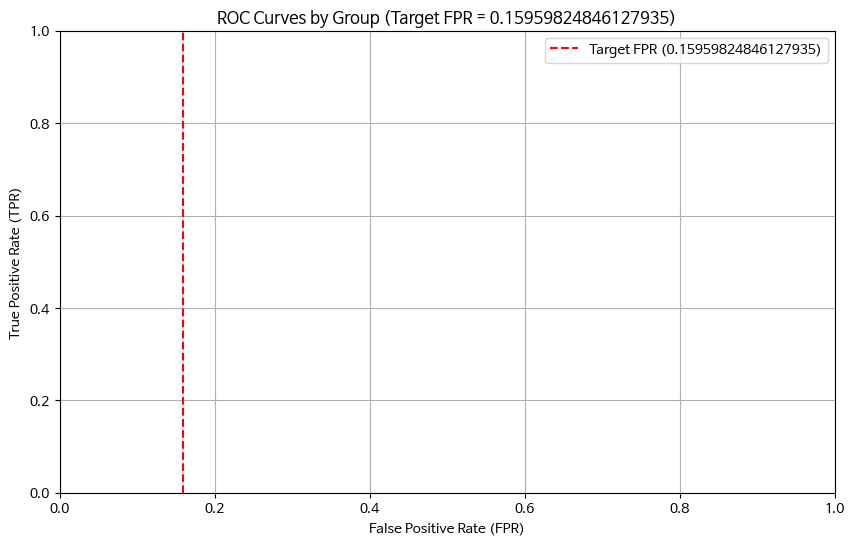

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.4098
PR-AUC : 0.2527
Recall    : 0.5319
Precision : 0.3332

       [최종 - 집단별 임계값]       
Group F: 1.0000
Group M: 1.0000

       [최종 - 연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.252194  0.543139  0.803346  0.196654  0.456861
M             0.263208  0.518571  0.786233  0.213767  0.481429

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.011015
tpr               0.024567
tnr               0.017113
fpr               0.017113
fnr               0.024567
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.

 [Step 0] Base Model (보정 전) 학습 결과



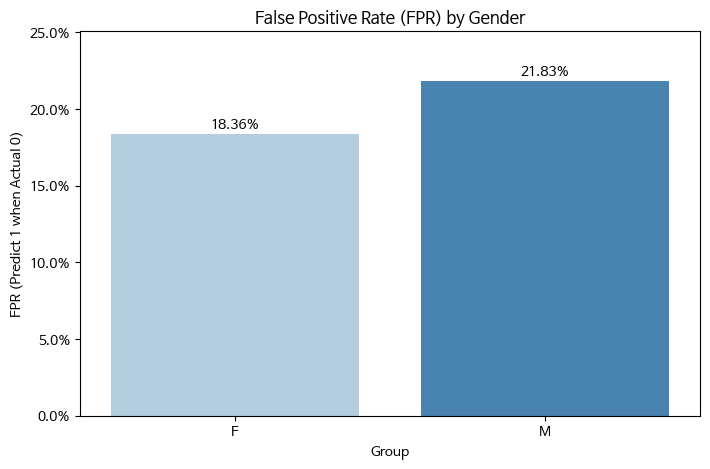

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.239600,23.96%,53.28%,18.36%,35.65%
1,M,0.162200,0.268400,26.84%,52.68%,21.83%,31.84%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



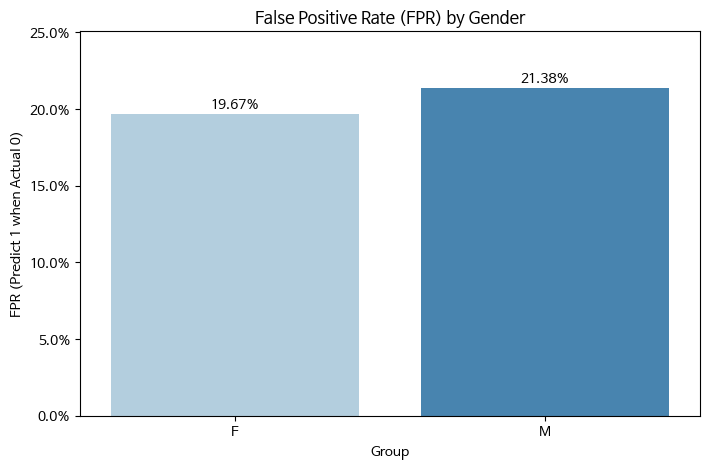

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.252200,25.22%,54.31%,19.67%,34.52%
1,M,0.162200,0.263200,26.32%,51.86%,21.38%,31.96%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



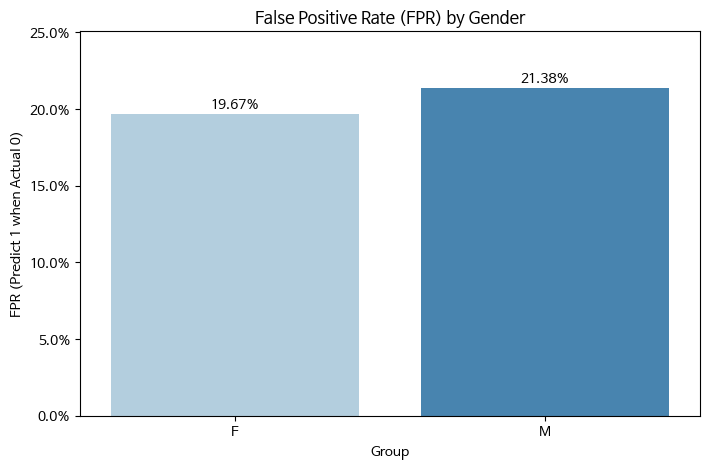

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.252200,25.22%,54.31%,19.67%,34.52%
1,M,0.162200,0.263200,26.32%,51.86%,21.38%,31.96%


In [ ]:
var_name = 'gender'
x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post, mitigator, thresholds_manual = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.239555  0.532828  0.816429  0.183571  0.467172
M             0.268364  0.526786  0.781669  0.218331  0.473214
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.028809
tpr               0.006042
tnr               0.034760
fpr               0.034760
fnr               0.006042
dtype: float64


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3441
PR-AUC : 0.2510
Recall    : 0.2608
Precision : 0.5057

       [집단별 임계값]       
연령대: F       | 추정 임계값: 0.6480
연령대: M       | 추정 임계값: 0.4607

       [연령대별 공정성 세부 지표]       
        selection_rate       tpr       tnr       fpr       fnr
gender                                                        
F             0.083222  0.273086  0.953022  0.046978  0.726914
M             0.082957  0.246250  0.948659  0.051341  0.753750

       [집단 간 최대 격차 (Max Gap)]      
selection_rate    0.000265
tpr               0.026836
tnr               0.004363
fpr               0.004363
fnr               0.026836
dtype: float64

 [Step 0] Base Model (보정 전) 학습 결과


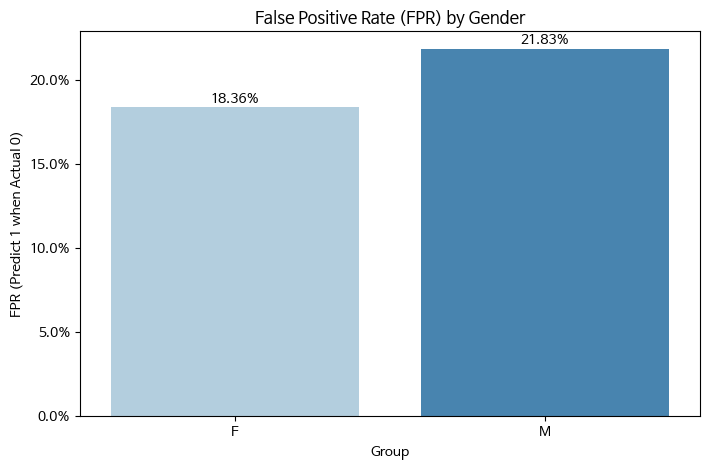

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.239600,23.96%,53.28%,18.36%,35.65%
1,M,0.162200,0.268400,26.84%,52.68%,21.83%,31.84%



 [Step 3] Base Model (보정 전) 학습 결과


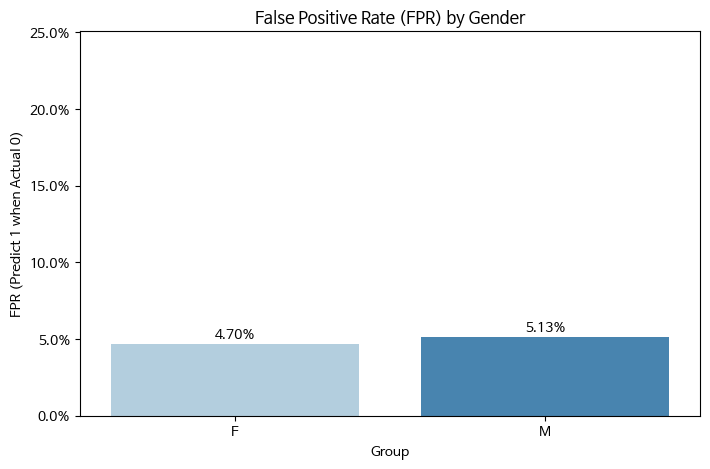

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.083200,8.32%,27.31%,4.70%,52.60%
1,M,0.162200,0.083000,8.30%,24.62%,5.13%,48.15%


In [ ]:
var_name = 'gender'
y_pred_final, thresholds_auto = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

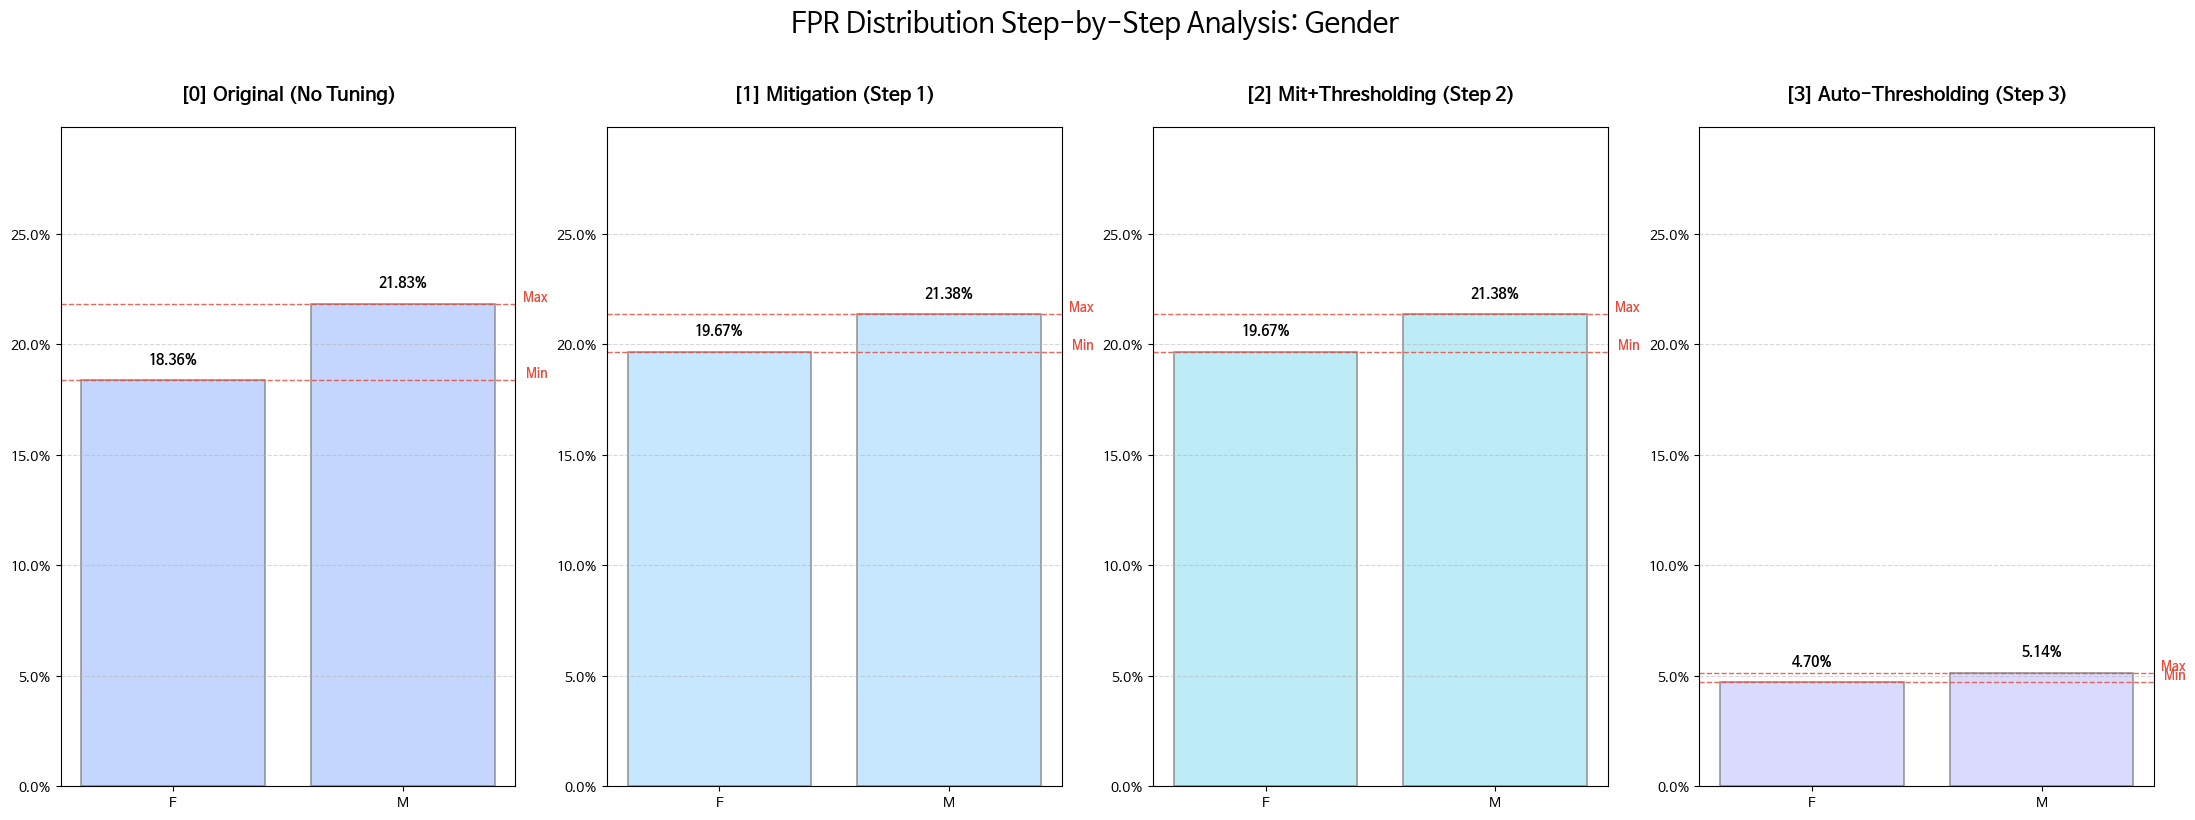

In [ ]:
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive, y_pred_org, y_pred_mit, y_pred_post, y_pred_final, mitigator, thresholds_manual, thresholds_auto)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


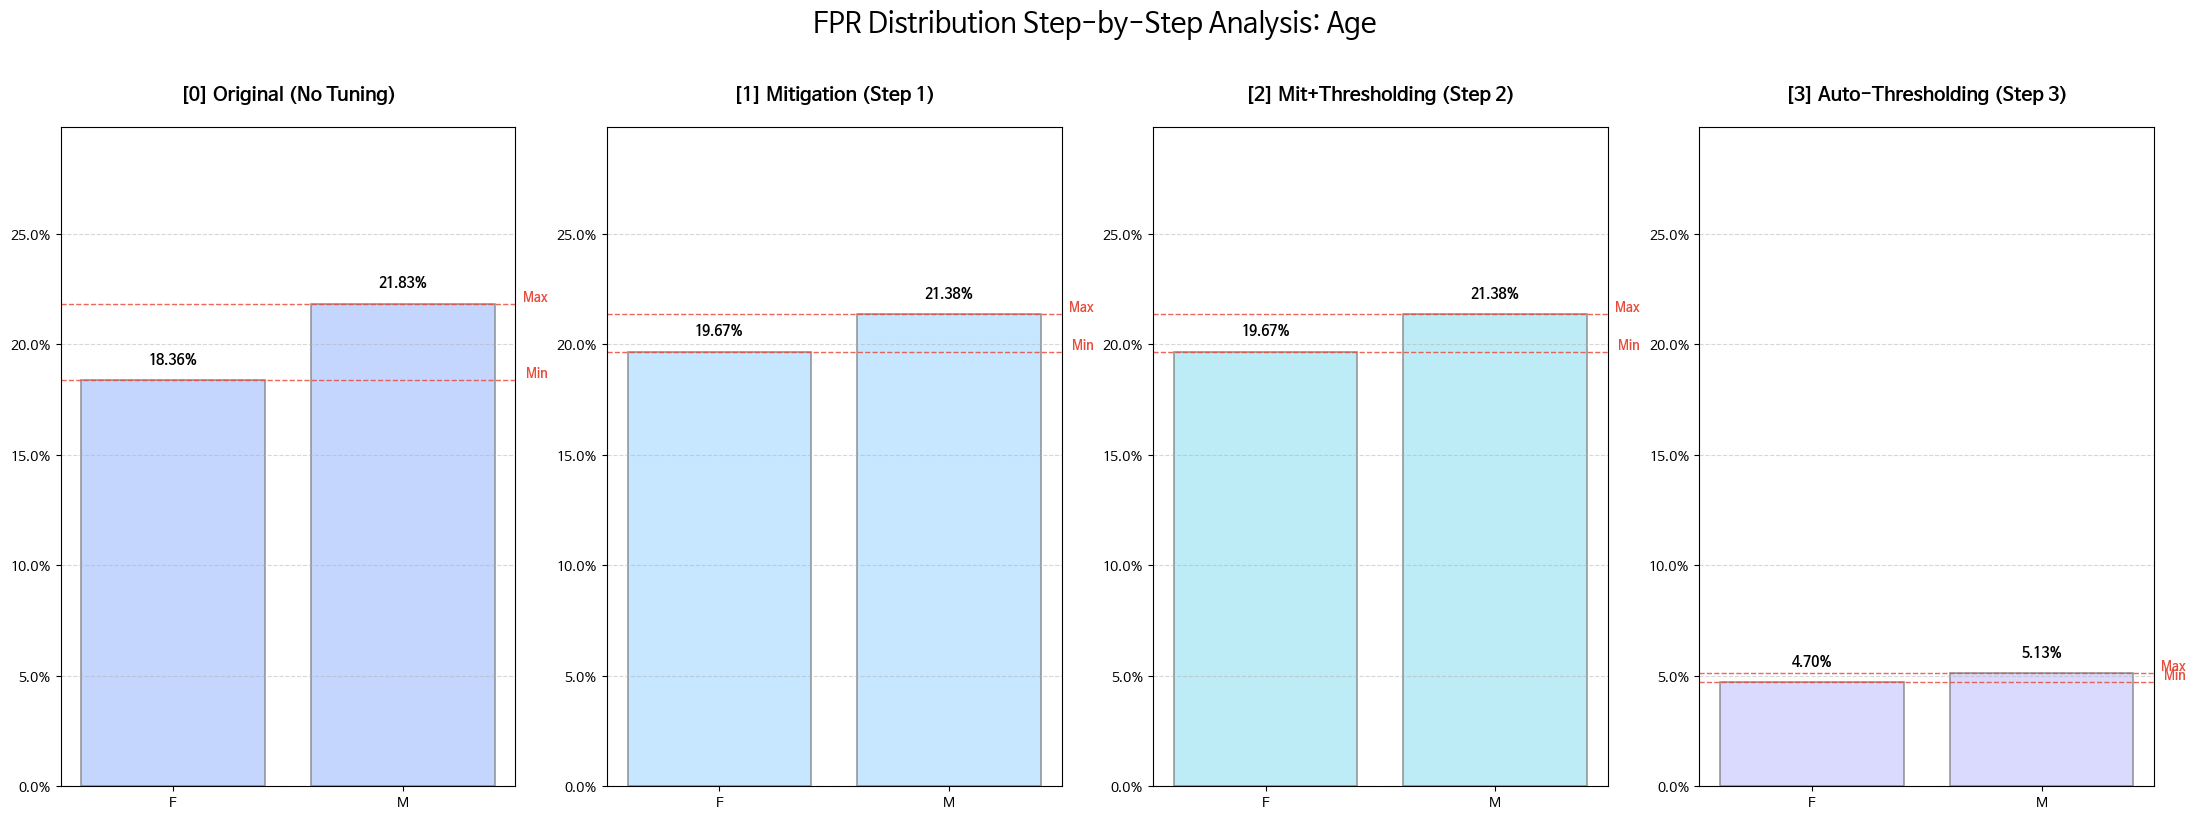

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 나이

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.384385  0.603424  0.677451  0.322549  0.396576
20s         0.417143  0.643213  0.643525  0.356475  0.356787
30s         0.351971  0.581238  0.707723  0.292277  0.418762
40s         0.267346  0.506121  0.783605  0.216395  0.493879
50s         0.184126  0.446188  0.856335  0.143665  0.553812
60s         0.083713  0.335673  0.939604  0.060396  0.664327
70s+        0.099531  0.377717  0.929413  0.070587  0.622283
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.333430
tpr               0.307540
tnr               0.296079
fpr               0.296079
fnr               0.307540
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlea

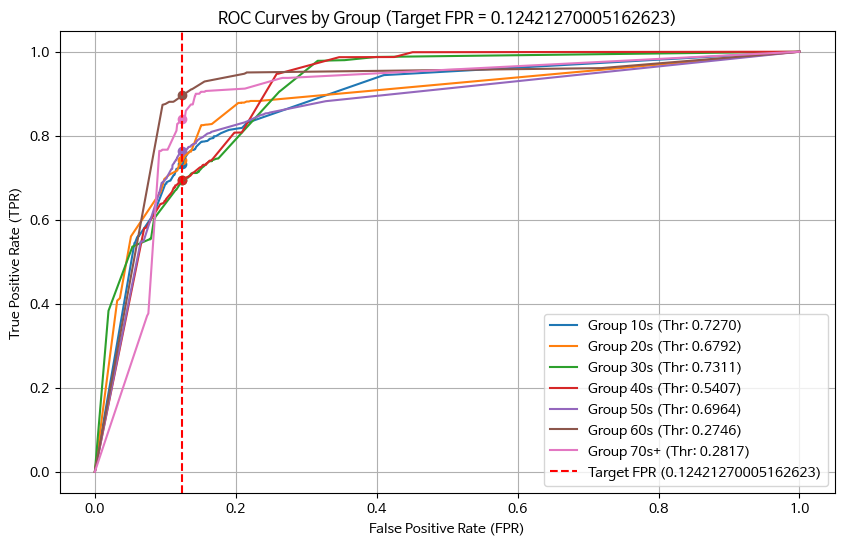

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3964
PR-AUC : 0.3333
Recall    : 0.4384
Precision : 0.3617

       [최종 - 집단별 임계값]       
Group 10s: 0.7270
Group 20s: 0.6792
Group 30s: 0.7311
Group 40s: 0.5407
Group 50s: 0.6964
Group 60s: 0.2746
Group 70s+: 0.2817

       [최종 - 연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.200154  0.413697  0.860130  0.139870  0.586303
20s         0.222707  0.449183  0.838070  0.161930  0.550817
30s         0.182253  0.388423  0.871427  0.128573  0.611577
40s         0.194403  0.415725  0.852823  0.147177  0.584275
50s         0.206018  0.467862  0.834410  0.165590  0.532138
60s         0.201308  0.560234  0.831908  0.168092  0.439766
70s+        0.174563  0.515399  0.860899  0.139101  0.484601

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.048144
tpr               0.171811
tnr               0.039519
fpr               0.039519
fn

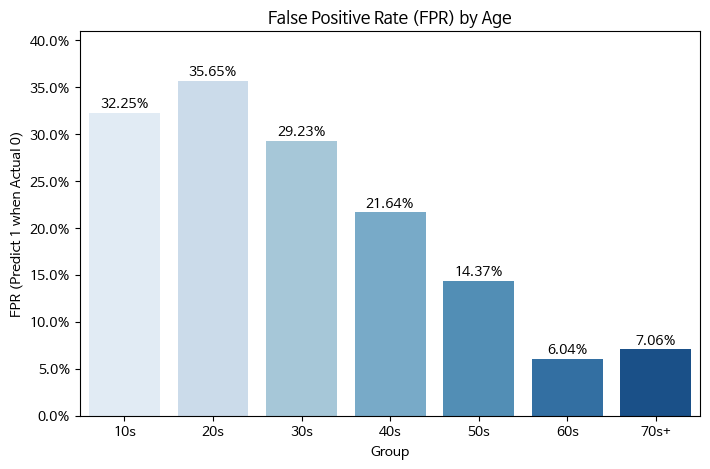

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.384400,38.44%,60.34%,32.25%,34.56%
1,20s,0.211600,0.417100,41.71%,64.32%,35.65%,32.62%
2,30s,0.206600,0.352000,35.20%,58.12%,29.23%,34.11%
3,40s,0.175900,0.267300,26.73%,50.61%,21.64%,33.29%
4,50s,0.133700,0.184100,18.41%,44.62%,14.37%,32.41%
5,60s,0.084700,0.083700,8.37%,33.57%,6.04%,33.96%
6,70s+,0.094200,0.099500,9.95%,37.77%,7.06%,35.76%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과

DEBUG - y_true 길이: 75667
DEBUG - y_pred 길이: 75667
DEBUG - groups  길이: 75667


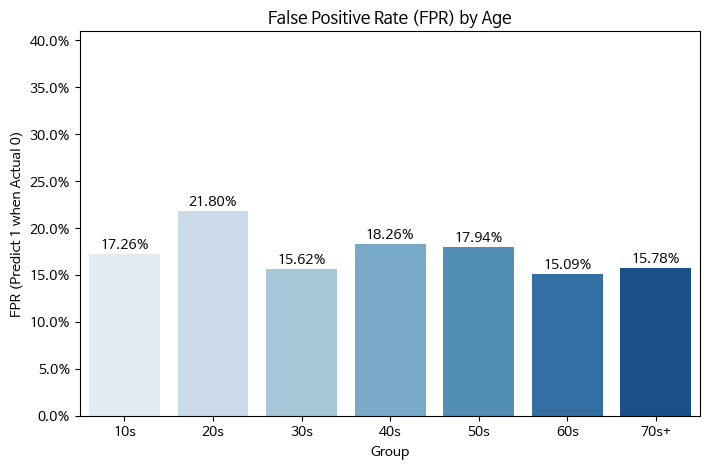

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.227500,22.75%,42.21%,17.26%,40.84%
1,20s,0.211600,0.272600,27.26%,47.62%,21.80%,36.96%
2,30s,0.206600,0.209000,20.90%,41.16%,15.62%,40.69%
3,40s,0.175900,0.228400,22.84%,44.30%,18.26%,34.11%
4,50s,0.133700,0.219400,21.94%,47.83%,17.94%,29.16%
5,60s,0.084700,0.176800,17.68%,45.73%,15.09%,21.90%
6,70s+,0.094200,0.189100,18.91%,49.00%,15.78%,24.42%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과

DEBUG - y_true 길이: 75667
DEBUG - y_pred 길이: 75667
DEBUG - groups  길이: 75667


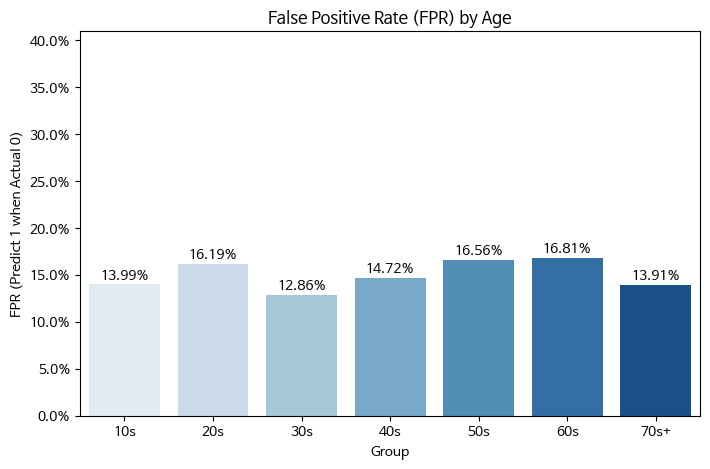

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.200200,20.02%,41.37%,13.99%,45.50%
1,20s,0.211600,0.222700,22.27%,44.92%,16.19%,42.67%
2,30s,0.206600,0.182300,18.23%,38.84%,12.86%,44.03%
3,40s,0.175900,0.194400,19.44%,41.57%,14.72%,37.61%
4,50s,0.133700,0.206000,20.60%,46.79%,16.56%,30.37%
5,60s,0.084700,0.201300,20.13%,56.02%,16.81%,23.57%
6,70s+,0.094200,0.174600,17.46%,51.54%,13.91%,27.82%


In [ ]:
var_name = 'age'
x_test_sensitive_2, y_pred_org, y_pred_mit_2, y_pred_post_2, mitigator_2, thresholds_manual_2 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.384385  0.603424  0.677451  0.322549  0.396576
20s         0.417143  0.643213  0.643525  0.356475  0.356787
30s         0.351971  0.581238  0.707723  0.292277  0.418762
40s         0.267346  0.506121  0.783605  0.216395  0.493879
50s         0.184126  0.446188  0.856335  0.143665  0.553812
60s         0.083713  0.335673  0.939604  0.060396  0.664327
70s+        0.099531  0.377717  0.929413  0.070587  0.622283
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.333430
tpr               0.307540
tnr               0.296079
fpr               0.296079
fnr               0.307540
dtype: float64


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00612177 0.00612177 0.00612177 ... 0.00612177 0.00612177 0.00612177]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.2903
PR-AUC : 0.2276
Recall    : 0.2080
Precision : 0.4808

       [집단별 임계값]       
연령대: 10s     | 추정 임계값: 0.5623
연령대: 20s     | 추정 임계값: 0.5952
연령대: 30s     | 추정 임계값: 0.7394
연령대: 40s     | 추정 임계값: 0.5160
연령대: 50s     | 추정 임계값: 0.5168
연령대: 60s     | 추정 임계값: 0.5142
연령대: 70s+    | 추정 임계값: 0.4804

       [연령대별 공정성 세부 지표]       
      selection_rate       tpr       tnr       fpr       fnr
age                                                         
10s         0.075077  0.198812  0.959854  0.040146  0.801188
20s         0.090977  0.241649  0.949456  0.050544  0.758351
30s         0.069685  0.201996  0.964765  0.035235  0.798004
40s         0.067561  0.184557  0.957404  0.042596  0.815443
50s         0.068573  0.214499  0.953958  0.046042  0.785501
60s         0.061522  0.228070  0.953891  0.046109  0.771930
70s+        0.061972  0.223732  0.954858  0.045142  0.776268

       [집단 간 최대 격차 (Max Gap)]      
selection_rate    0.029456
tpr            

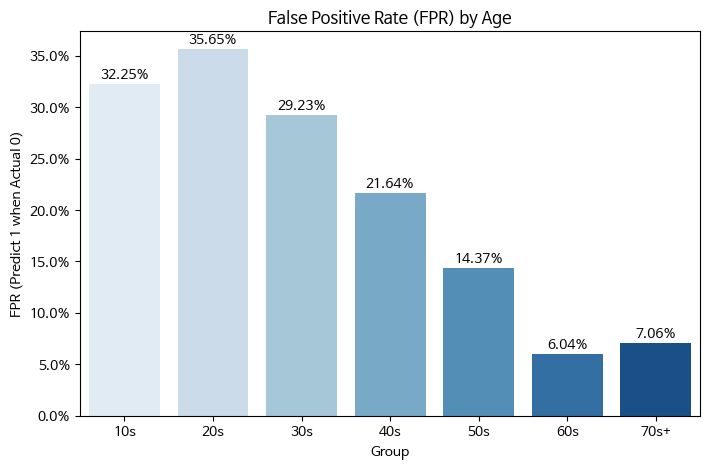

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.384400,38.44%,60.34%,32.25%,34.56%
1,20s,0.211600,0.417100,41.71%,64.32%,35.65%,32.62%
2,30s,0.206600,0.352000,35.20%,58.12%,29.23%,34.11%
3,40s,0.175900,0.267300,26.73%,50.61%,21.64%,33.29%
4,50s,0.133700,0.184100,18.41%,44.62%,14.37%,32.41%
5,60s,0.084700,0.083700,8.37%,33.57%,6.04%,33.96%
6,70s+,0.094200,0.099500,9.95%,37.77%,7.06%,35.76%



 [Step 3] Base Model (보정 전) 학습 결과
DEBUG - y_true 길이: 75667
DEBUG - y_pred 길이: 75667
DEBUG - groups  길이: 75667


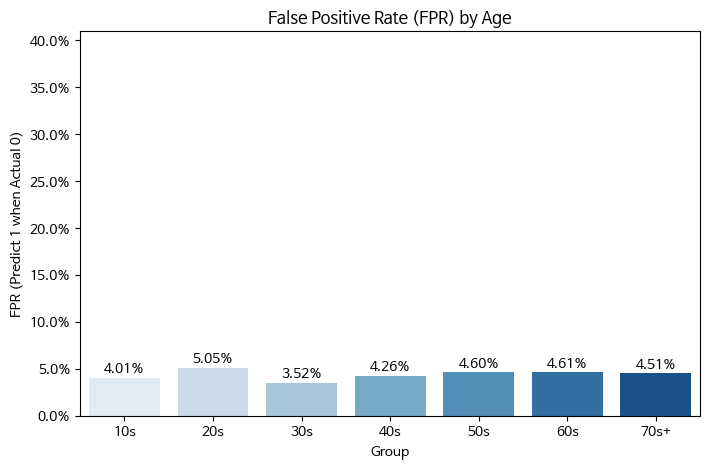

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.075100,7.51%,19.88%,4.01%,58.30%
1,20s,0.211600,0.091000,9.10%,24.16%,5.05%,56.20%
2,30s,0.206600,0.069700,6.97%,20.20%,3.52%,59.88%
3,40s,0.175900,0.067600,6.76%,18.46%,4.26%,48.04%
4,50s,0.133700,0.068600,6.86%,21.45%,4.60%,41.84%
5,60s,0.084700,0.061500,6.15%,22.81%,4.61%,31.40%
6,70s+,0.094200,0.062000,6.20%,22.37%,4.51%,34.02%


In [ ]:
var_name = 'age'
y_pred_final_2, thresholds_auto_2 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

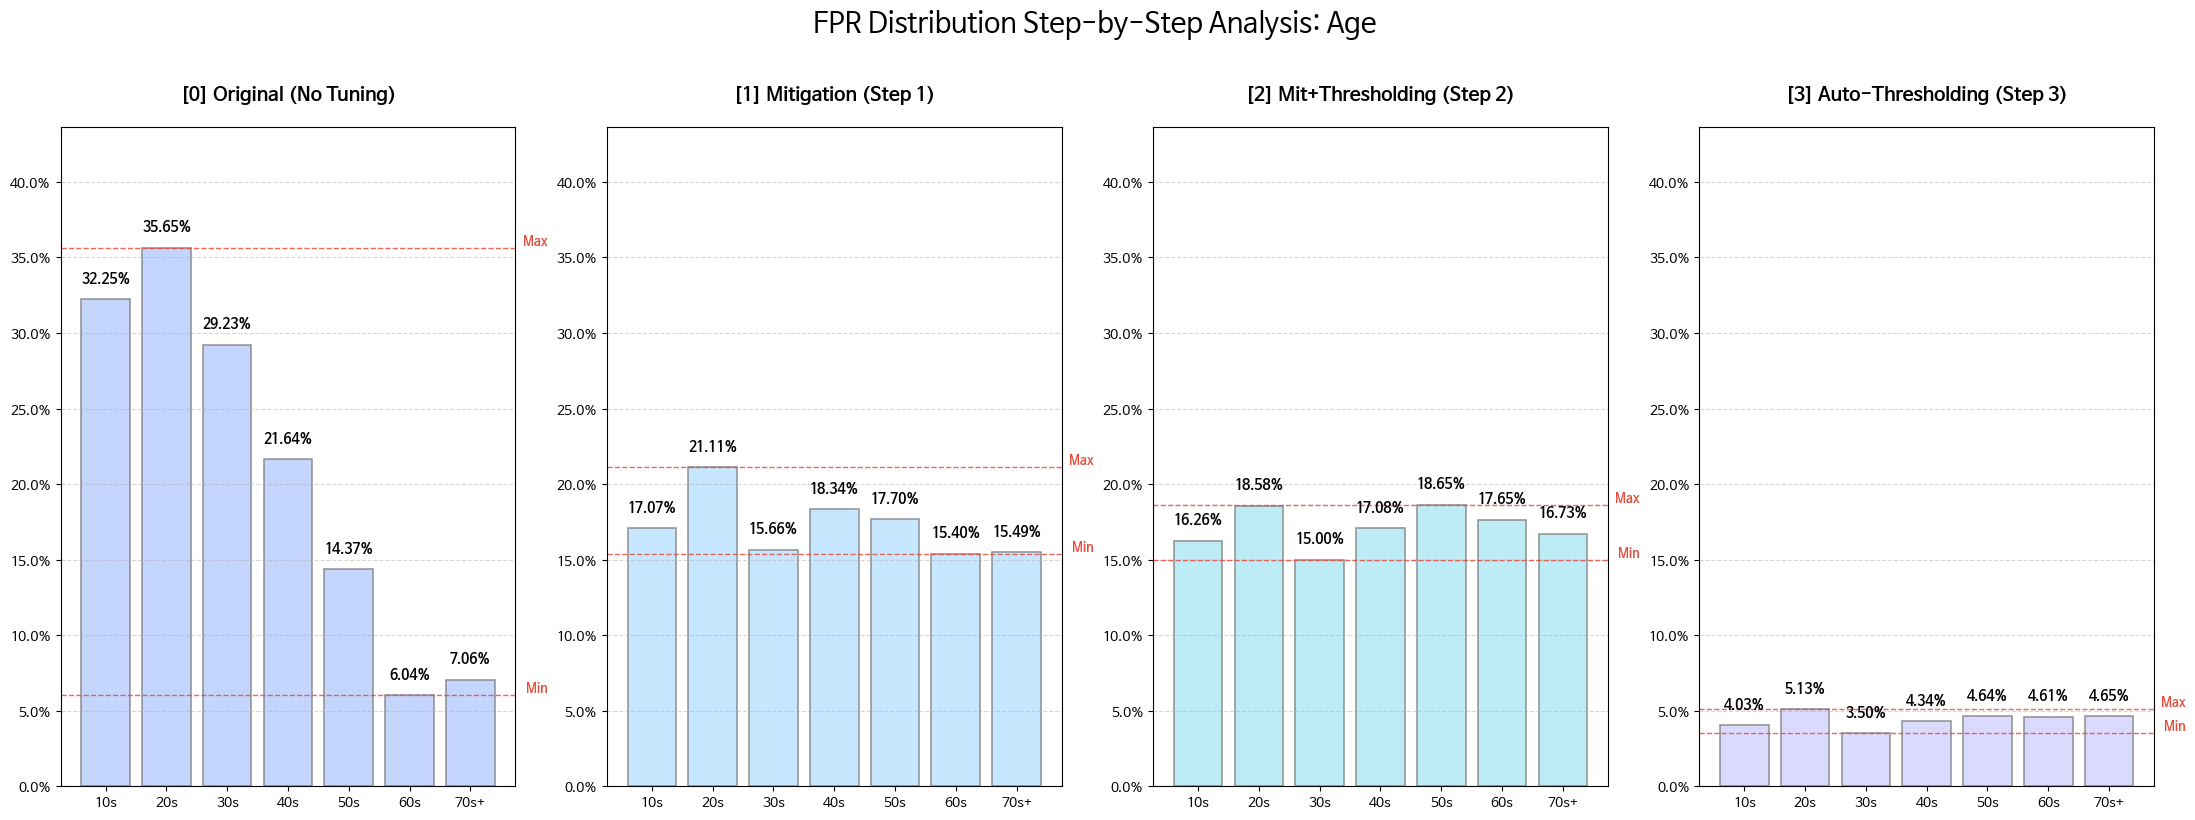

In [ ]:
y_preds = [y_pred_org, y_pred_mit_2, y_pred_post_2, y_pred_final_2]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive_2, y_pred_org, y_pred_mit_2, y_pred_post_2, y_pred_final_2, mitigator_2, thresholds_manual_2, thresholds_auto_2)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


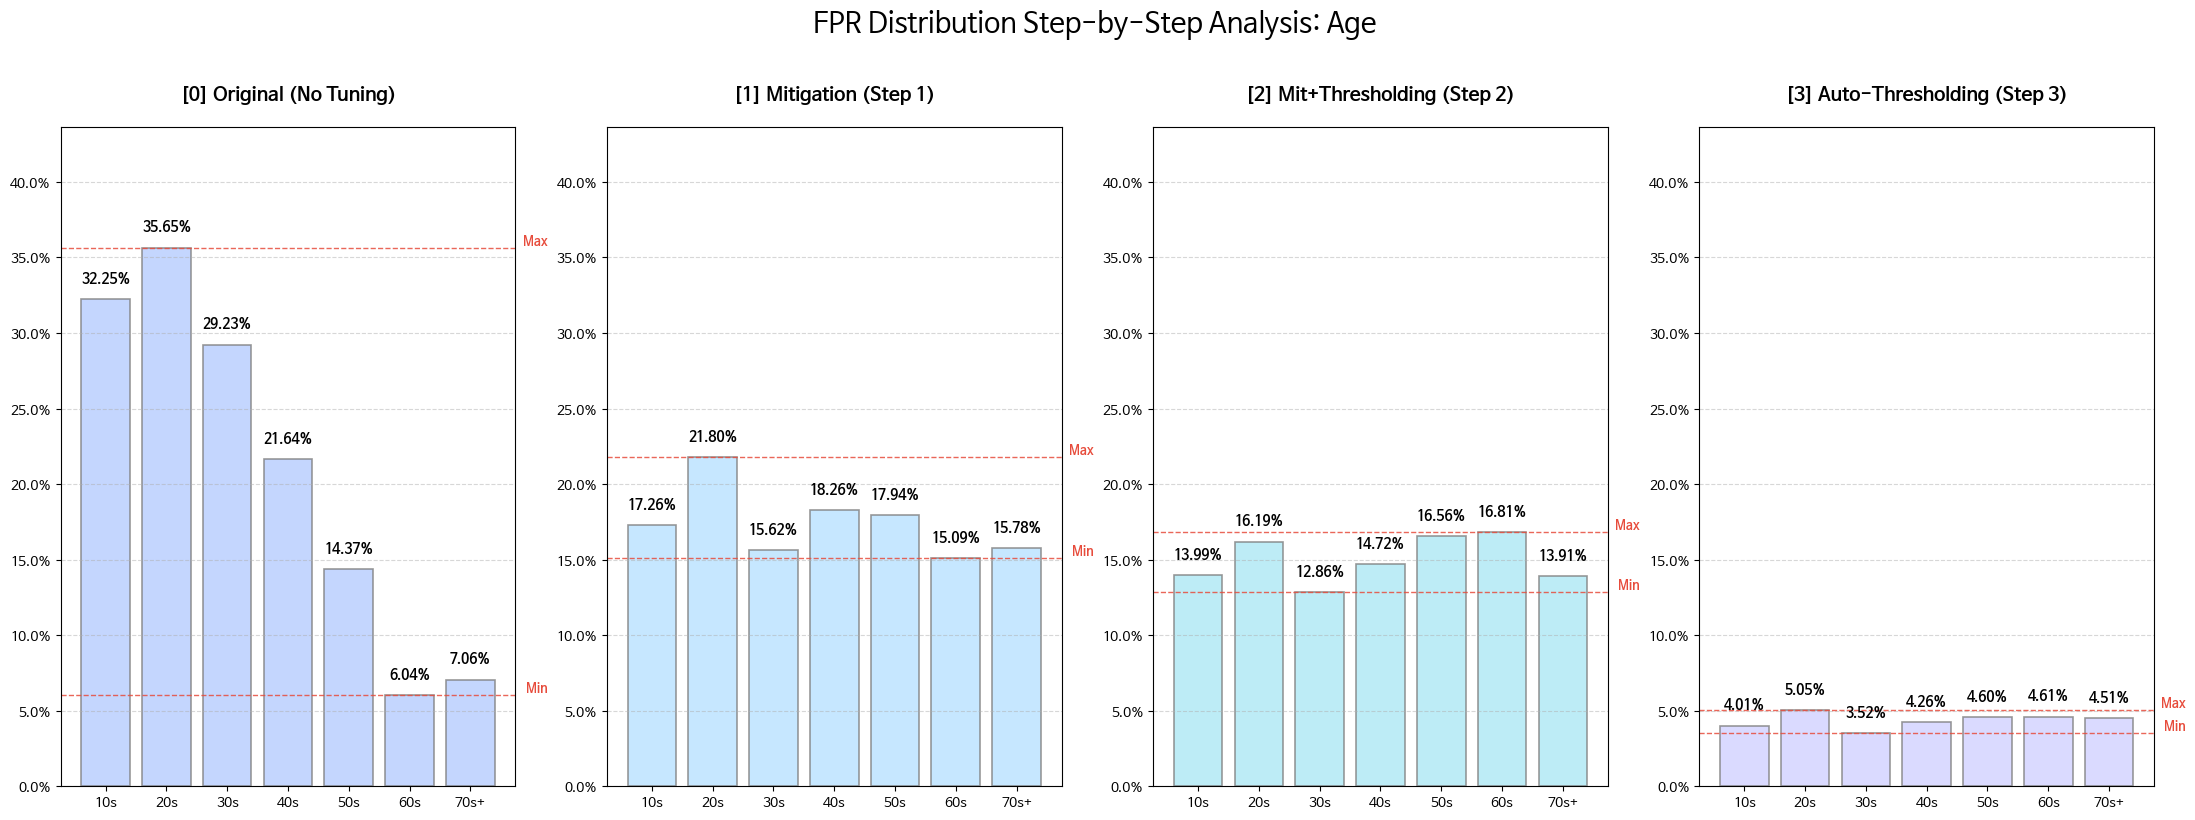

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 성별 & 나이

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.088408  0.358149  0.936127  0.063873  0.641851
F_장년           0.333624  0.576687  0.732234  0.267766  0.423313
F_중년           0.204604  0.480447  0.845070  0.154930  0.519553
F_청년           0.376022  0.603235  0.689212  0.310788  0.396765
M_고령           0.099911  0.379070  0.929626  0.070374  0.620930
M_장년           0.342434  0.557183  0.710162  0.289838  0.442817
M_중년           0.251972  0.483191  0.789920  0.210080  0.516809
M_청년           0.381836  0.586361  0.673873  0.326127  0.413639
       [학습 전 결과]       
F1-Score  : 0.4121
PR-AUC : 0.4014
Recall    : 0.5223
Precision : 0.3403
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.293428
tpr               0.245086
tnr               0.262254
fpr               0.262254
fnr 

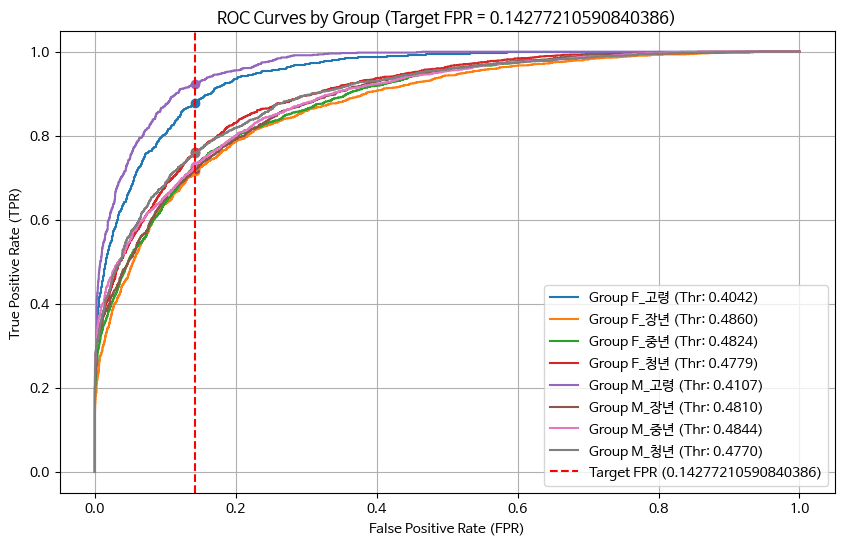

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.4004
PR-AUC : 0.3991
Recall    : 0.4677
Precision : 0.3501

       [최종 - 집단별 임계값]       
Group F_고령: 0.4042
Group F_장년: 0.4860
Group F_중년: 0.4824
Group F_청년: 0.4779
Group M_고령: 0.4107
Group M_장년: 0.4810
Group M_중년: 0.4844
Group M_청년: 0.4770

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.195940  0.563380  0.837482  0.162518  0.436620
F_장년           0.206649  0.449387  0.859122  0.140878  0.550613
F_중년           0.221483  0.498883  0.828471  0.171529  0.501117
F_청년           0.233165  0.452291  0.829748  0.170252  0.547709
M_고령           0.220071  0.565116  0.816437  0.183563  0.434884
M_장년           0.202634  0.400279  0.845773  0.154227  0.599721
M_중년           0.217189  0.450890  0.825152  0.174848  0.549110
M_청년           0.229867  0.441029  0.827649  0.172351  0.558971

       [최종 - 집단 간 최대 격차 (Max Gap)] 

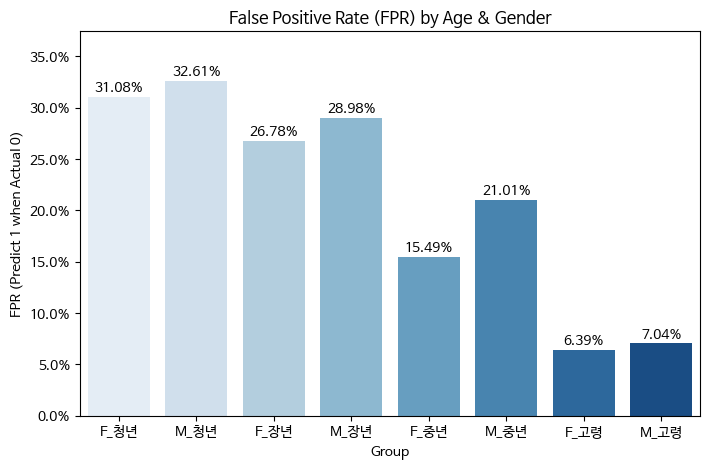

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.376000,37.60%,60.32%,31.08%,35.79%
1,M_청년,0.214100,0.381800,38.18%,58.64%,32.61%,32.87%
2,F_장년,0.213200,0.333600,33.36%,57.67%,26.78%,36.85%
3,M_장년,0.196700,0.342400,34.24%,55.72%,28.98%,32.01%
4,F_중년,0.152600,0.204600,20.46%,48.04%,15.49%,35.83%
5,M_중년,0.153400,0.252000,25.20%,48.32%,21.01%,29.41%
6,F_고령,0.083400,0.088400,8.84%,35.81%,6.39%,33.78%
7,M_고령,0.095700,0.099900,9.99%,37.91%,7.04%,36.30%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



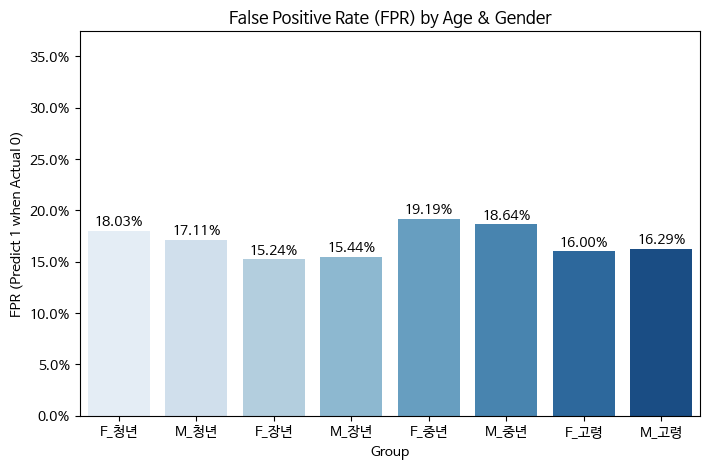

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.238000,23.80%,43.88%,18.03%,41.13%
1,M_청년,0.214100,0.222900,22.29%,41.31%,17.11%,39.67%
2,F_장년,0.213200,0.212600,21.26%,43.51%,15.24%,43.62%
3,M_장년,0.196700,0.198500,19.85%,37.87%,15.44%,37.53%
4,F_중년,0.152600,0.238200,23.82%,49.55%,19.19%,31.75%
5,M_중년,0.153400,0.224500,22.45%,43.44%,18.64%,29.68%
6,F_고령,0.083400,0.181100,18.11%,41.25%,16.00%,18.99%
7,M_고령,0.095700,0.188800,18.88%,43.37%,16.29%,21.98%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



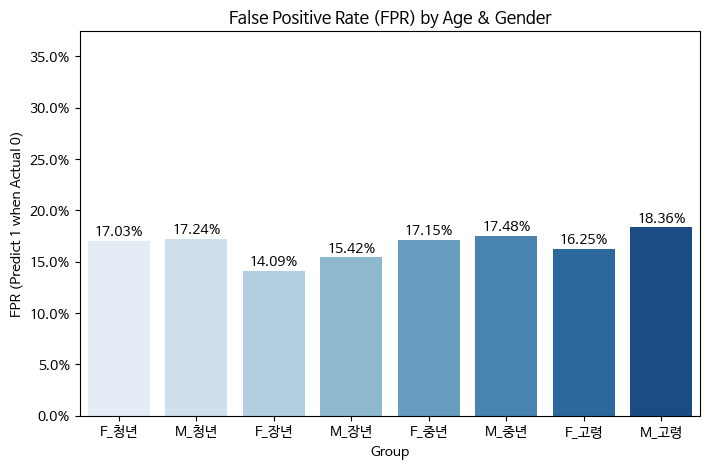

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.233200,23.32%,45.23%,17.03%,43.27%
1,M_청년,0.214100,0.229900,22.99%,44.10%,17.24%,41.07%
2,F_장년,0.213200,0.206600,20.66%,44.94%,14.09%,46.36%
3,M_장년,0.196700,0.202600,20.26%,40.03%,15.42%,38.86%
4,F_중년,0.152600,0.221500,22.15%,49.89%,17.15%,34.37%
5,M_중년,0.153400,0.217200,21.72%,45.09%,17.48%,31.84%
6,F_고령,0.083400,0.195900,19.59%,56.34%,16.25%,23.97%
7,M_고령,0.095700,0.220100,22.01%,56.51%,18.36%,24.57%


In [84]:
var_name = 'age_gender'
x_test_sensitive_3, y_pred_org, y_pred_mit_3, y_pred_post_3, mitigator_3, thresholds_manual_3  = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.084969  0.340040  0.938232  0.061768  0.659960
F_장년           0.359128  0.598671  0.705776  0.294224  0.401329
F_중년           0.201364  0.483240  0.849396  0.150604  0.516760
F_청년           0.383117  0.614555  0.683331  0.316669  0.385445
M_고령           0.097686  0.375581  0.931718  0.068282  0.624419
M_장년           0.358623  0.573919  0.694108  0.305892  0.426081
M_중년           0.249039  0.479895  0.792786  0.207214  0.520105
M_청년           0.396075  0.601453  0.659866  0.340134  0.398547
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.311106
tpr               0.274515
tnr               0.278366
fpr               0.278366
fnr               0.274515
dtype: float6

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.01105409 0.01105409 0.01105409 ... 0.01105409 0.7539822  0.22536575]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3164
PR-AUC : 0.2334
Recall    : 0.2408
Precision : 0.4610

       [집단별 임계값]       
연령대: F_고령    | 추정 임계값: 0.4443
연령대: F_장년    | 추정 임계값: 0.7095
연령대: F_중년    | 추정 임계값: 0.5216
연령대: F_청년    | 추정 임계값: 0.5296
연령대: M_고령    | 추정 임계값: 0.5100
연령대: M_장년    | 추정 임계값: 0.5207
연령대: M_중년    | 추정 임계값: 0.4960
연령대: M_청년    | 추정 임계값: 0.5535

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
gen_age                                                        
F_고령           0.077084  0.274648  0.940886  0.059114  0.725352
F_장년           0.087956  0.247444  0.955257  0.044743  0.752556
F_중년           0.084569  0.269274  0.948692  0.051308  0.730726
F_청년           0.095118  0.232884  0.944436  0.055564  0.767116
M_고령           0.075545  0.268605  0.944882  0.055118  0.731395
M_장년           0.084511  0.216876  0.947908  0.052092  0.783124
M_중년           0.083620  0.214239  0.940045  0.059955  0.785761
M_청년           0.08854

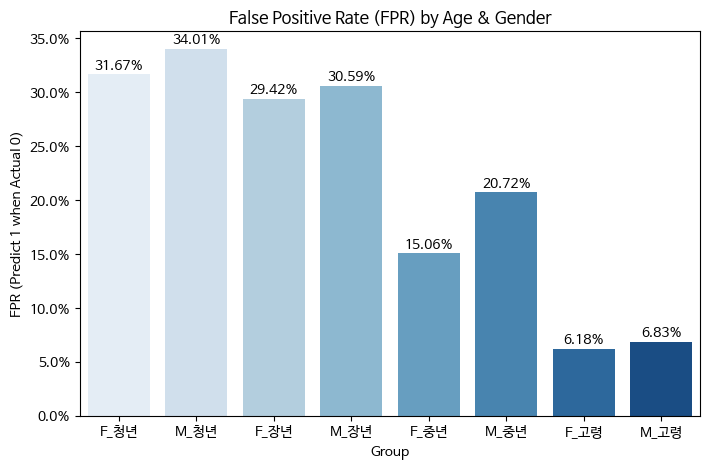

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.383100,38.31%,61.46%,31.67%,35.78%
1,M_청년,0.214100,0.396100,39.61%,60.15%,34.01%,32.51%
2,F_장년,0.213200,0.359100,35.91%,59.87%,29.42%,35.54%
3,M_장년,0.196700,0.358600,35.86%,57.39%,30.59%,31.48%
4,F_중년,0.152600,0.201400,20.14%,48.32%,15.06%,36.62%
5,M_중년,0.153400,0.249000,24.90%,47.99%,20.72%,29.56%
6,F_고령,0.083400,0.085000,8.50%,34.00%,6.18%,33.37%
7,M_고령,0.095700,0.097700,9.77%,37.56%,6.83%,36.79%



 [Step 3] ThresholdOptimizer (보정 후) 학습 결과


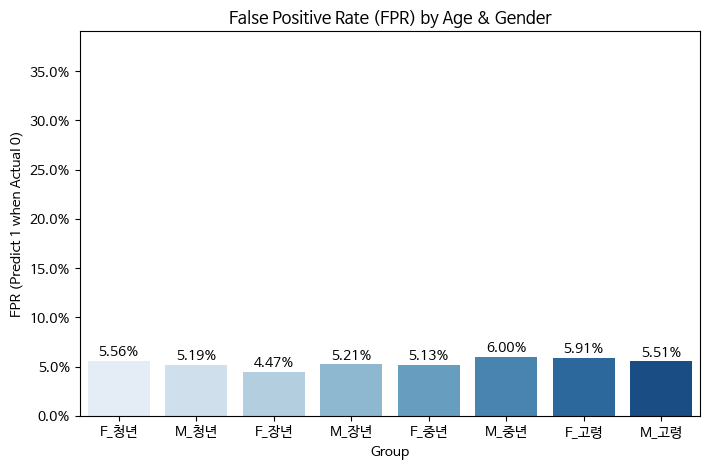

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.095100,9.51%,23.29%,5.56%,54.61%
1,M_청년,0.214100,0.088500,8.85%,22.30%,5.19%,53.92%
2,F_장년,0.213200,0.088000,8.80%,24.74%,4.47%,59.98%
3,M_장년,0.196700,0.084500,8.45%,21.69%,5.21%,50.49%
4,F_중년,0.152600,0.084600,8.46%,26.93%,5.13%,48.59%
5,M_중년,0.153400,0.083600,8.36%,21.42%,6.00%,39.30%
6,F_고령,0.083400,0.077100,7.71%,27.46%,5.91%,29.71%
7,M_고령,0.095700,0.075500,7.55%,26.86%,5.51%,34.02%


In [ ]:
var_name = 'age_gender'
y_pred_final_3, thresholds_auto_3 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

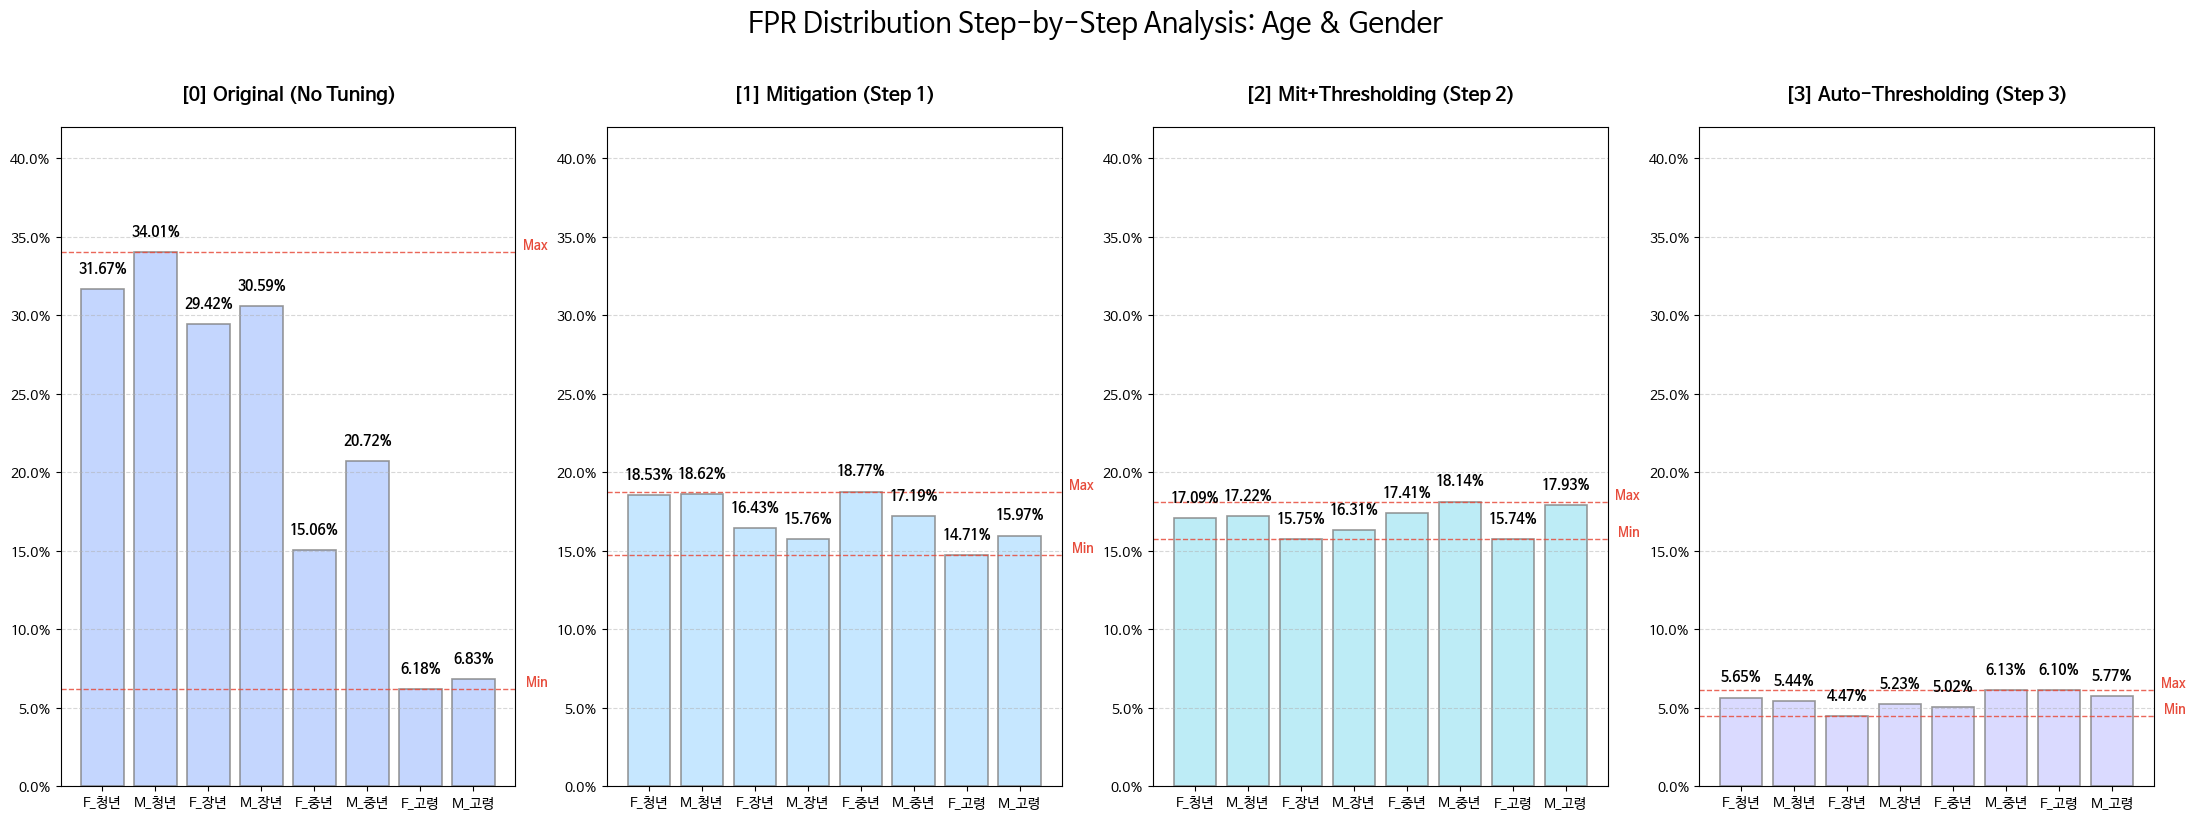

In [ ]:
y_preds = [y_pred_org, y_pred_mit_3, y_pred_post_3, y_pred_final_3]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive_3, y_pred_org, y_pred_mit_3, y_pred_post_3, y_pred_final_3, mitigator_3, thresholds_manual_3, thresholds_auto_3)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


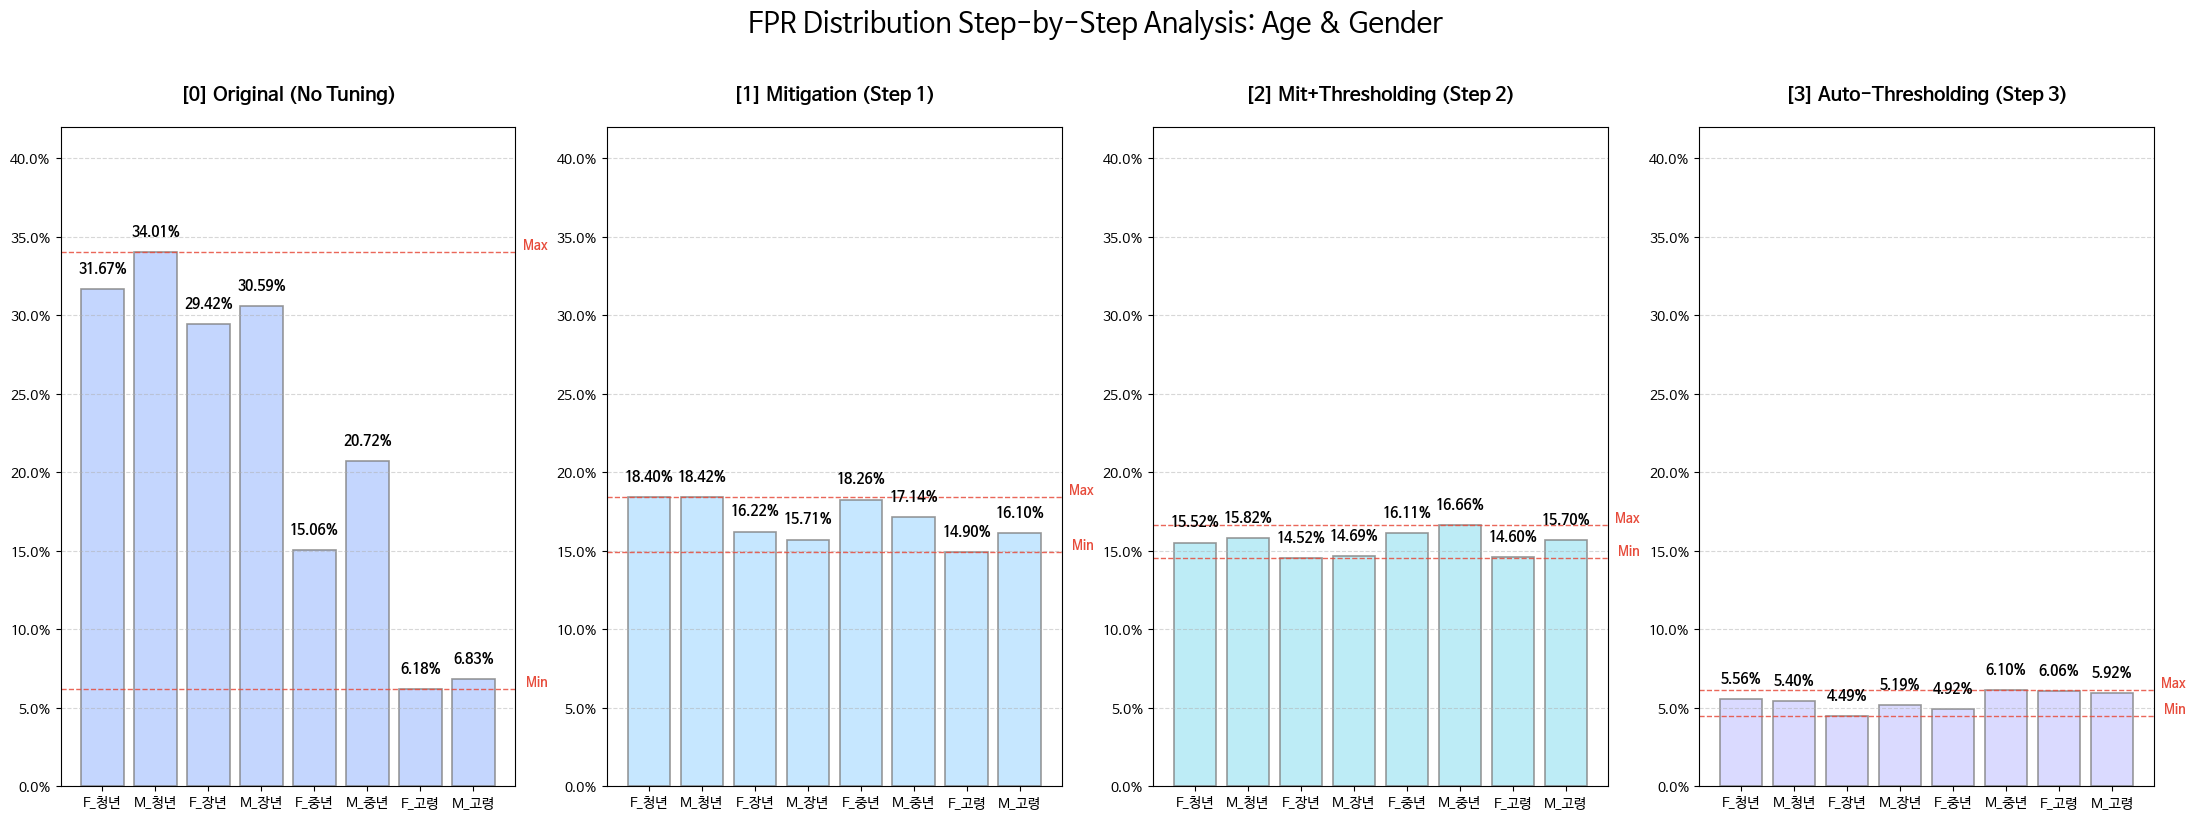

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 지역

##### `C_H`



 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.094899  0.267857  0.931601  0.068399  0.732143
H2             0.251762  0.528653  0.809927  0.190073  0.471347
H3             0.262239  0.514423  0.798684  0.201316  0.485577
H4             0.360722  0.605729  0.697211  0.302789  0.394271
H5             0.325350  0.593168  0.741735  0.258265  0.406832
H6             0.231605  0.512500  0.815167  0.184833  0.487500
Unknown        0.170130  0.515385  0.873659  0.126341  0.484615
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.265823
tpr               0.337872
tnr               0.234389
fpr               0.234389
fnr               0.337872
dtype: float64

 [Step 2] Fairlearn Mitig

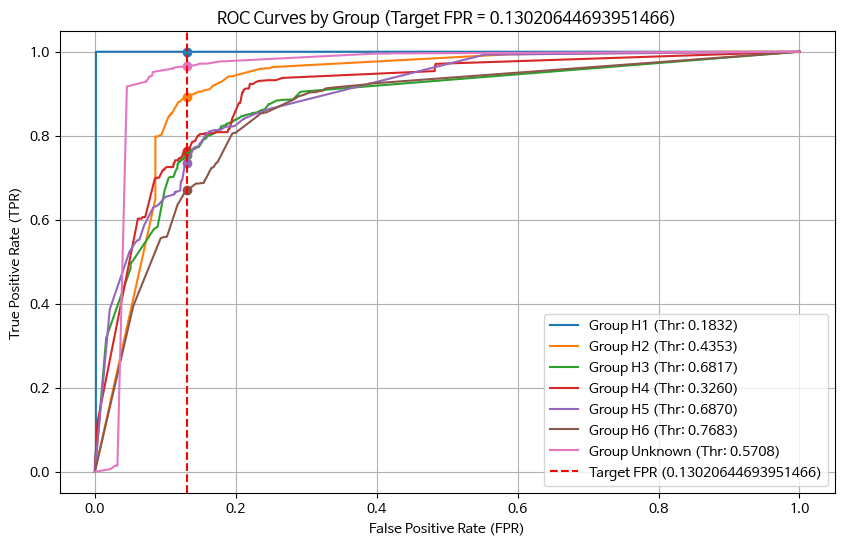

⚠️ 튜닝 후 FPR 격차가 더 벌어짐 (0.0660 → 0.1180), mitigator 원래 예측값으로 대체합니다.
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3921
PR-AUC : 0.3283
Recall    : 0.4860
Precision : 0.3286

       [최종 - 집단별 임계값]       
Group H1: 0.1832
Group H2: 0.4353
Group H3: 0.6817
Group H4: 0.3260
Group H5: 0.6870
Group H6: 0.7683
Group Unknown: 0.5708

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.168446  0.285714  0.849521  0.150479  0.714286
H2             0.220439  0.420487  0.824130  0.175870  0.579513
H3             0.201954  0.431090  0.853400  0.146600  0.568910
H4             0.256001  0.439764  0.787450  0.212550  0.560236
H5             0.234681  0.493789  0.830222  0.169778  0.506211
H6             0.249542  0.528947  0.796982  0.203018  0.471053
Unknown        0.232035  0.488462  0.800488  0.199512  0.511538

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0

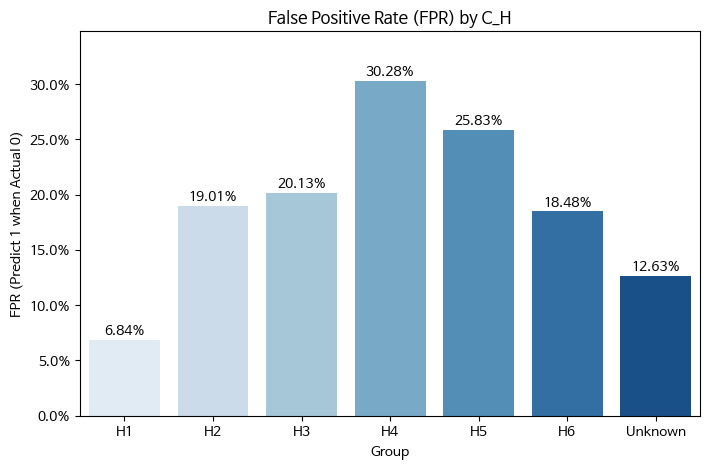

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.094900,9.49%,26.79%,6.84%,37.50%
1,H2,0.182200,0.251800,25.18%,52.87%,19.01%,38.26%
2,H3,0.194600,0.262200,26.22%,51.44%,20.13%,38.17%
3,H4,0.191200,0.360700,36.07%,60.57%,30.28%,32.11%
4,H5,0.200300,0.325300,32.53%,59.32%,25.83%,36.52%
5,H6,0.142700,0.231600,23.16%,51.25%,18.48%,31.59%
6,Unknown,0.112600,0.170100,17.01%,51.54%,12.63%,34.10%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



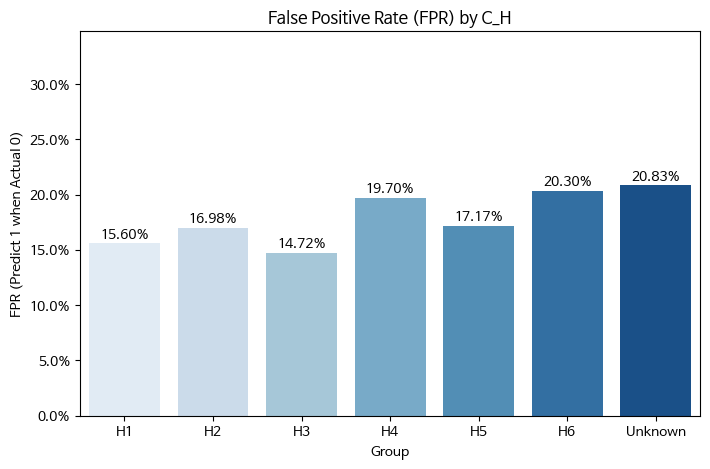

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.179100,17.91%,33.04%,15.60%,24.50%
1,H2,0.182200,0.216400,21.64%,42.55%,16.98%,35.83%
2,H3,0.194600,0.204100,20.41%,43.96%,14.72%,41.90%
3,H4,0.191200,0.245700,24.57%,45.16%,19.70%,35.15%
4,H5,0.200300,0.236100,23.61%,49.30%,17.17%,41.83%
5,H6,0.142700,0.250000,25.00%,53.17%,20.30%,30.37%
6,Unknown,0.112600,0.245900,24.59%,54.23%,20.83%,24.82%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



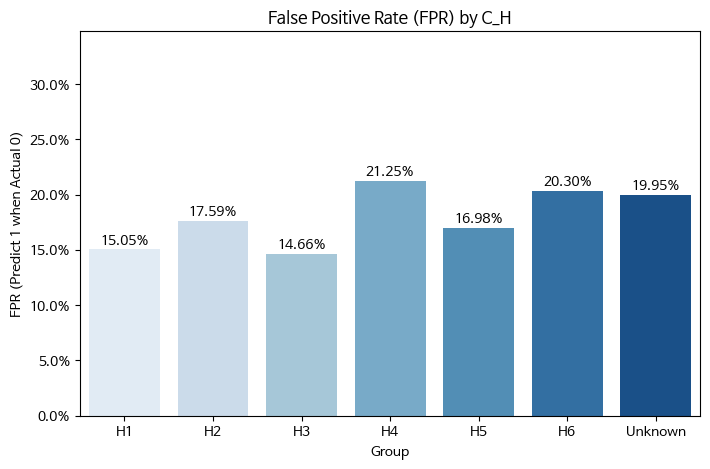

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.168400,16.84%,28.57%,15.05%,22.54%
1,H2,0.182200,0.220400,22.04%,42.05%,17.59%,34.75%
2,H3,0.194600,0.202000,20.20%,43.11%,14.66%,41.53%
3,H4,0.191200,0.256000,25.60%,43.98%,21.25%,32.85%
4,H5,0.200300,0.234700,23.47%,49.38%,16.98%,42.15%
5,H6,0.142700,0.249500,24.95%,52.89%,20.30%,30.26%
6,Unknown,0.112600,0.232000,23.20%,48.85%,19.95%,23.69%


In [ ]:
var_name = 'c_h'
x_test_sensitive_4, y_pred_org, y_pred_mit_4, y_pred_post_4, mitigator_4, thresholds_manual_4 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.094899  0.267857  0.931601  0.068399  0.732143
H2             0.251762  0.528653  0.809927  0.190073  0.471347
H3             0.262239  0.514423  0.798684  0.201316  0.485577
H4             0.360722  0.605729  0.697211  0.302789  0.394271
H5             0.325350  0.593168  0.741735  0.258265  0.406832
H6             0.231605  0.512500  0.815167  0.184833  0.487500
Unknown        0.170130  0.515385  0.873659  0.126341  0.484615
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.265823
tpr               0.337872
tnr               0.234389
fpr               0.234389
fnr               0.337872
dtype: float64


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.54997669 0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.10703594 0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.10703594
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.0251861  0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.10703594 0.0251861  0.0251861
 0.0251861  0.0251861  0.0251861  0.54997669 

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3522
PR-AUC : 0.2462
Recall    : 0.2858
Precision : 0.4587

       [집단별 임계값]       
연령대: H1      | 추정 임계값: 0.4277
연령대: H2      | 추정 임계값: 0.4916
연령대: H3      | 추정 임계값: 0.4410
연령대: H4      | 추정 임계값: 0.6703
연령대: H5      | 추정 임계값: 0.5652
연령대: H6      | 추정 임계값: 0.4769
연령대: Unknown | 추정 임계값: 0.5124

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_H_num                                                        
H1             0.099644  0.187500  0.913817  0.086183  0.812500
H2             0.096842  0.260029  0.939515  0.060485  0.739971
H3             0.103731  0.282585  0.939476  0.060524  0.717415
H4             0.106976  0.281382  0.934263  0.065737  0.718618
H5             0.109020  0.293478  0.937184  0.062816  0.706522
H6             0.099122  0.295395  0.933560  0.066440  0.704605
Unknown        0.080519  0.246154  0.940488  0.059512  0.753846

       [집단 간 최대 격차 (Max Gap)]      
selection_rate 

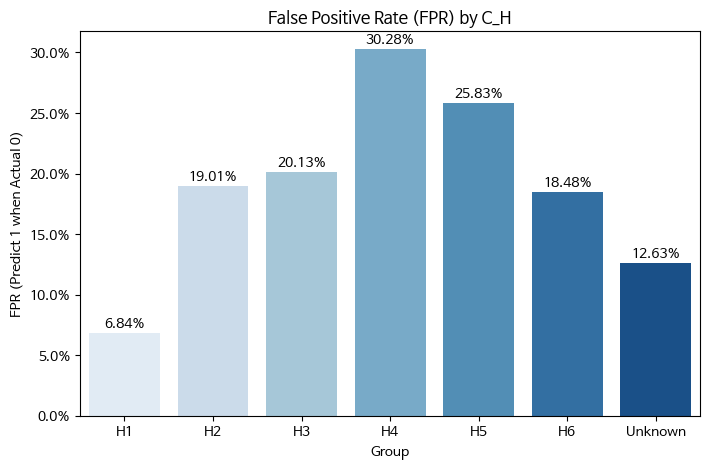

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.094900,9.49%,26.79%,6.84%,37.50%
1,H2,0.182200,0.251800,25.18%,52.87%,19.01%,38.26%
2,H3,0.194600,0.262200,26.22%,51.44%,20.13%,38.17%
3,H4,0.191200,0.360700,36.07%,60.57%,30.28%,32.11%
4,H5,0.200300,0.325300,32.53%,59.32%,25.83%,36.52%
5,H6,0.142700,0.231600,23.16%,51.25%,18.48%,31.59%
6,Unknown,0.112600,0.170100,17.01%,51.54%,12.63%,34.10%



 [Step 3] Base Model (보정 전) 학습 결과


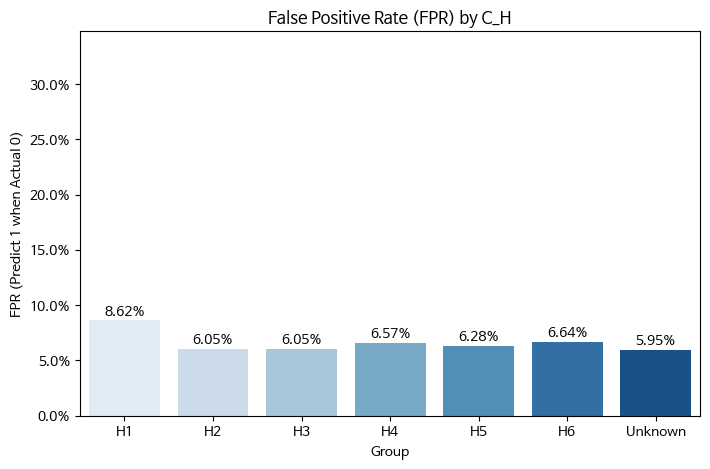

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.099600,9.96%,18.75%,8.62%,25.00%
1,H2,0.182200,0.096800,9.68%,26.00%,6.05%,48.92%
2,H3,0.194600,0.103700,10.37%,28.26%,6.05%,53.01%
3,H4,0.191200,0.107000,10.70%,28.14%,6.57%,50.30%
4,H5,0.200300,0.109000,10.90%,29.35%,6.28%,53.92%
5,H6,0.142700,0.099100,9.91%,29.54%,6.64%,42.54%
6,Unknown,0.112600,0.080500,8.05%,24.62%,5.95%,34.41%


In [ ]:
var_name = 'c_h'
y_pred_final_4, thresholds_auto_4 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

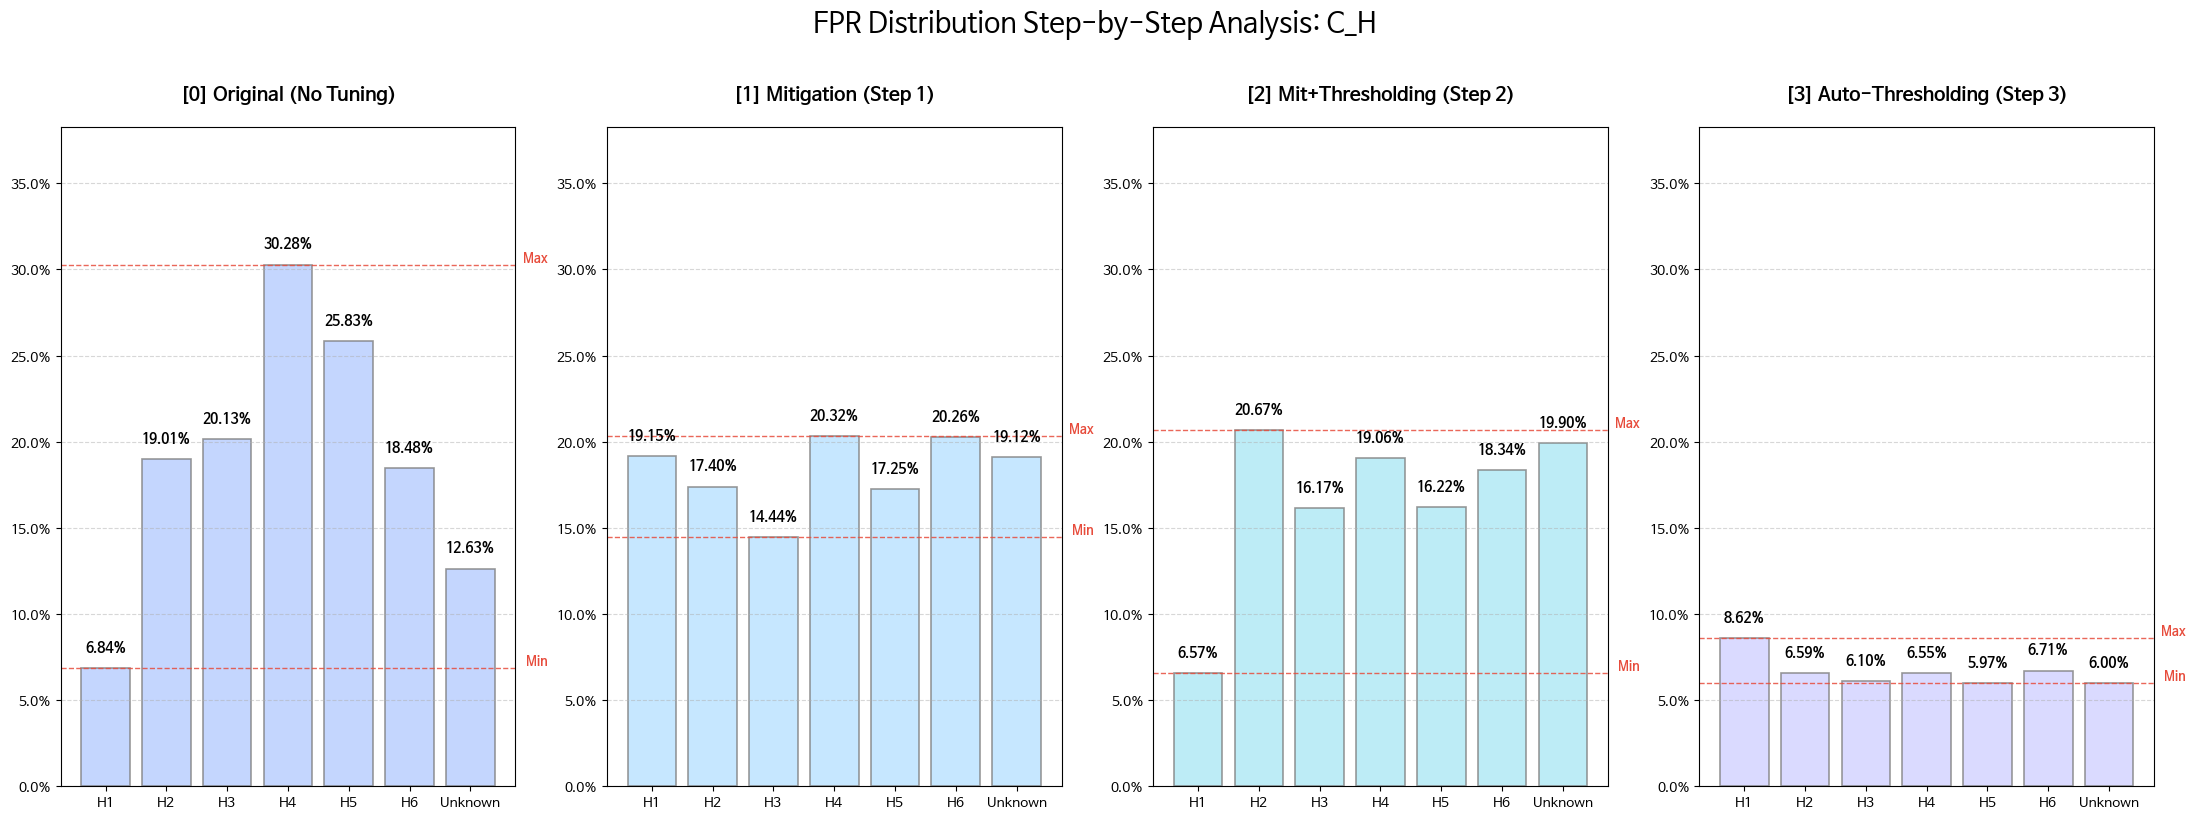

In [ ]:
y_preds = [y_pred_org, y_pred_mit_4, y_pred_post_4, y_pred_final_4]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive_4, y_pred_org, y_pred_mit_4, y_pred_post_4, y_pred_final_4, mitigator_4, thresholds_manual_4, thresholds_auto_4)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


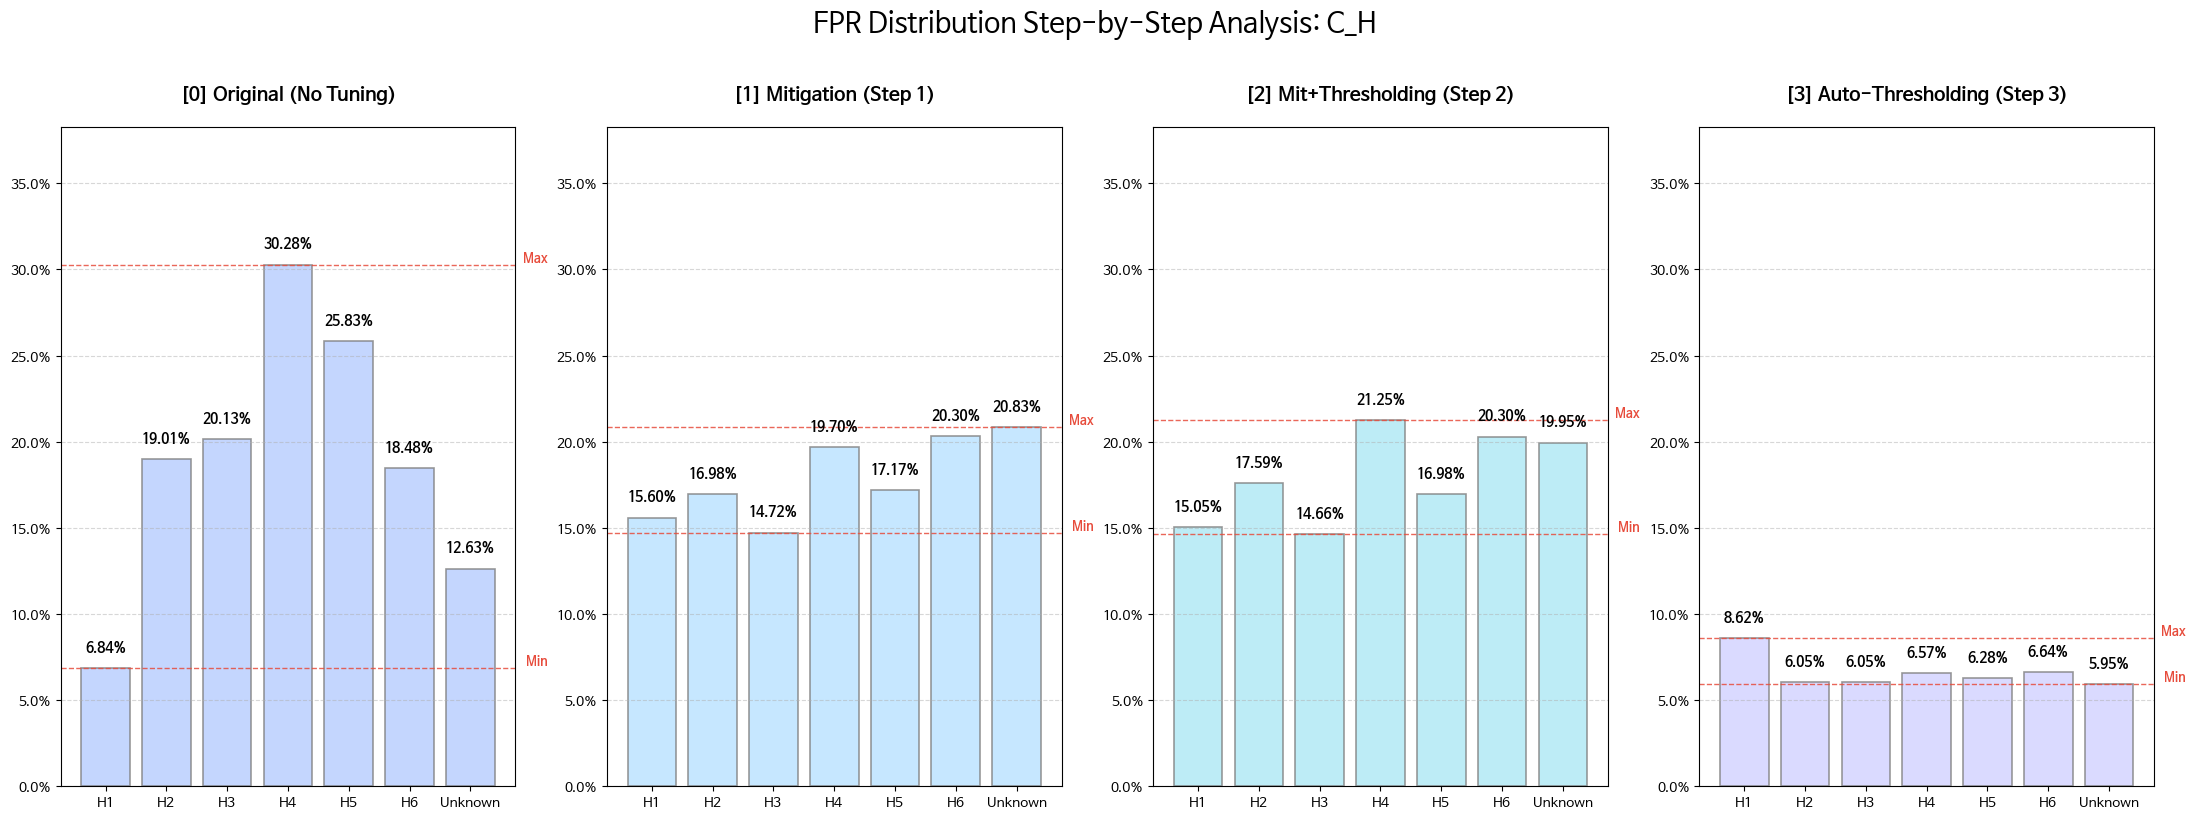

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

##### `C_GI`

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.281872  0.554707  0.791269  0.208731  0.445293
GI_2           0.377771  0.617468  0.694717  0.305283  0.382532
GI_3           0.372598  0.645769  0.699907  0.300093  0.354231
GI_4           0.218128  0.480692  0.825936  0.174064  0.519308
Unknown        0.153292  0.464589  0.887407  0.112593  0.535411
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.224479
tpr               0.181180
tnr               0.192690
fpr               0.192690
fnr               0.181180
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.3934
PR-AUC: 0.2955
Recall: 0.5168


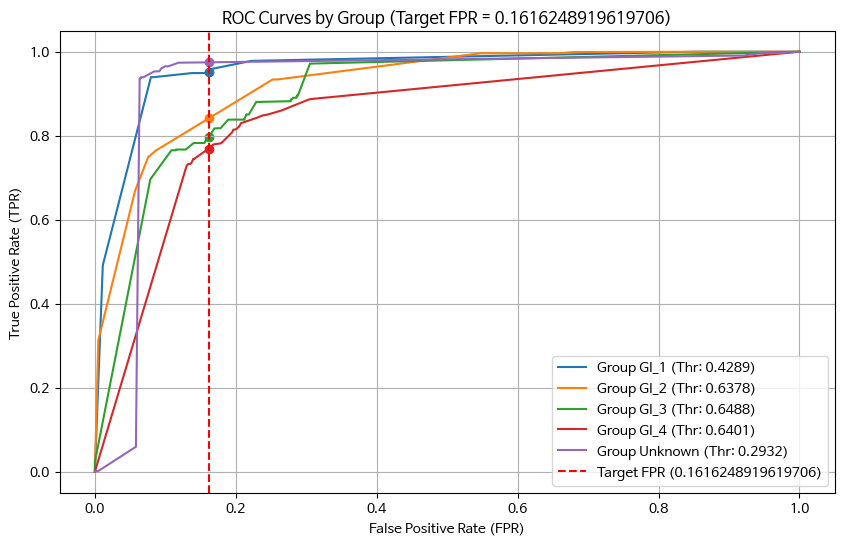

⚠️ 튜닝 후 FPR 격차가 더 벌어짐 (0.0251 → 0.0954), mitigator 원래 예측값으로 대체합니다.
       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3921
PR-AUC : 0.2955
Recall    : 0.5150
Precision : 0.3166

       [최종 - 집단별 임계값]       
Group GI_1: 0.4289
Group GI_2: 0.6378
Group GI_3: 0.6488
Group GI_4: 0.6401
Group Unknown: 0.2932

       [최종 - 연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.273265  0.470738  0.779673  0.220327  0.529262
GI_2           0.267725  0.477996  0.795864  0.204136  0.522004
GI_3           0.291310  0.543621  0.775657  0.224343  0.456379
GI_4           0.256899  0.517098  0.786768  0.213232  0.482902
Unknown        0.232886  0.490085  0.800741  0.199259  0.509915

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.058425
tpr               0.072883
tnr               0.025083
fpr               0.025083
fnr               0.072883
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료

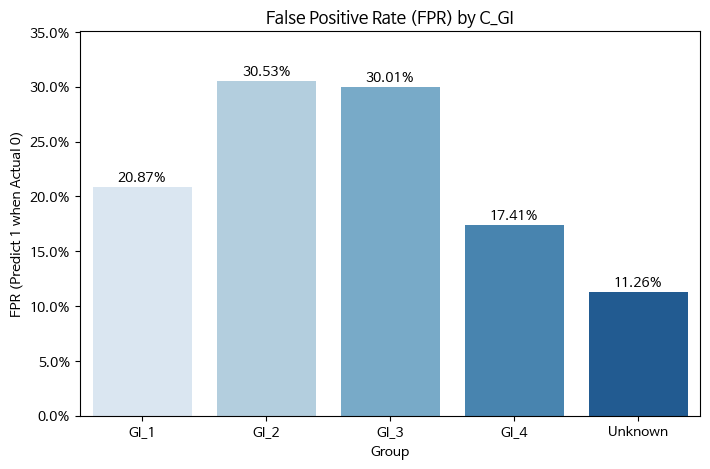

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.281900,28.19%,55.47%,20.87%,41.60%
1,GI_2,0.232200,0.377800,37.78%,61.75%,30.53%,37.95%
2,GI_3,0.209700,0.372600,37.26%,64.58%,30.01%,36.35%
3,GI_4,0.143700,0.218100,21.81%,48.07%,17.41%,31.67%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



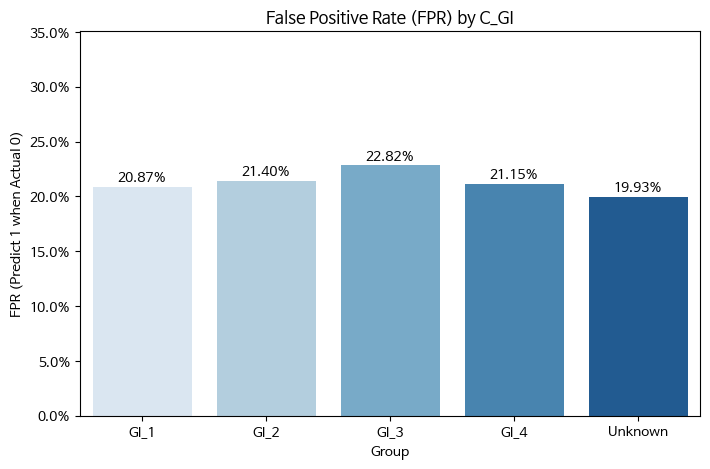

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.267900,26.79%,48.85%,20.87%,38.55%
1,GI_2,0.232200,0.276400,27.64%,48.27%,21.40%,40.56%
2,GI_3,0.209700,0.293500,29.35%,53.97%,22.82%,38.57%
3,GI_4,0.143700,0.256000,25.60%,52.11%,21.15%,29.25%
4,Unknown,0.115600,0.228000,22.80%,44.76%,19.93%,22.70%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



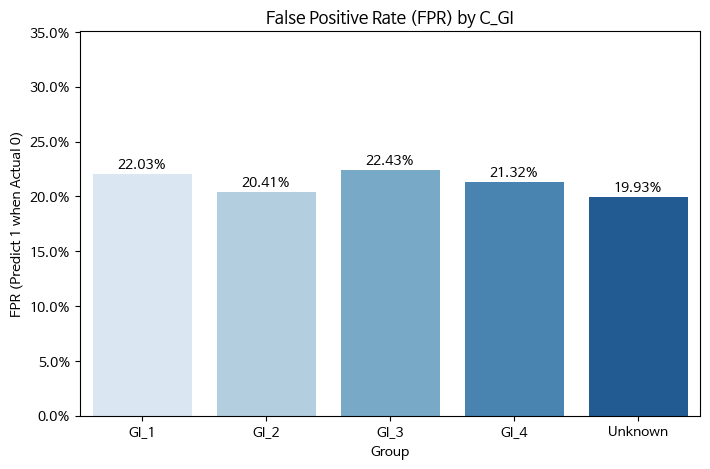

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.273300,27.33%,47.07%,22.03%,36.42%
1,GI_2,0.232200,0.267700,26.77%,47.80%,20.41%,41.46%
2,GI_3,0.209700,0.291300,29.13%,54.36%,22.43%,39.14%
3,GI_4,0.143700,0.256900,25.69%,51.71%,21.32%,28.93%
4,Unknown,0.115600,0.232900,23.29%,49.01%,19.93%,24.33%


In [ ]:
var_name = 'c_gi'
x_test_sensitive_5, y_pred_org, y_pred_mit_5, y_pred_post_5, mitigator_5, thresholds_manual_5 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.281872  0.554707  0.791269  0.208731  0.445293
GI_2           0.377771  0.617468  0.694717  0.305283  0.382532
GI_3           0.372598  0.645769  0.699907  0.300093  0.354231
GI_4           0.218128  0.480692  0.825936  0.174064  0.519308
Unknown        0.153292  0.464589  0.887407  0.112593  0.535411
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.224479
tpr               0.181180
tnr               0.192690
fpr               0.192690
fnr               0.181180
dtype: float64


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.02515337 0.02515337 0.02515337 ... 0.02515337 0.02515337 0.02515337]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3485
PR-AUC : 0.2409
Recall    : 0.2905
Precision : 0.4355

       [집단별 임계값]       
연령대: GI_1    | 추정 임계값: 0.4953
연령대: GI_2    | 추정 임계값: 0.5479
연령대: GI_3    | 추정 임계값: 0.6869
연령대: GI_4    | 추정 임계값: 0.4915
연령대: Unknown | 추정 임계값: 0.4841

       [연령대별 공정성 세부 지표]       
         selection_rate       tpr       tnr       fpr       fnr
C_GI                                                           
GI_1           0.101668  0.198473  0.924284  0.075716  0.801527
GI_2           0.121522  0.284360  0.927723  0.072277  0.715640
GI_3           0.121747  0.320912  0.931115  0.068885  0.679088
GI_4           0.103627  0.289299  0.927533  0.072467  0.710701
Unknown        0.099247  0.249292  0.920370  0.079630  0.750708

       [집단 간 최대 격차 (Max Gap)]      
selection_rate    0.022500
tpr               0.122439
tnr               0.010744
fpr               0.010744
fnr               0.122439
dtype: float64

 [Step 0] Base Model (보정 전) 학습 결과


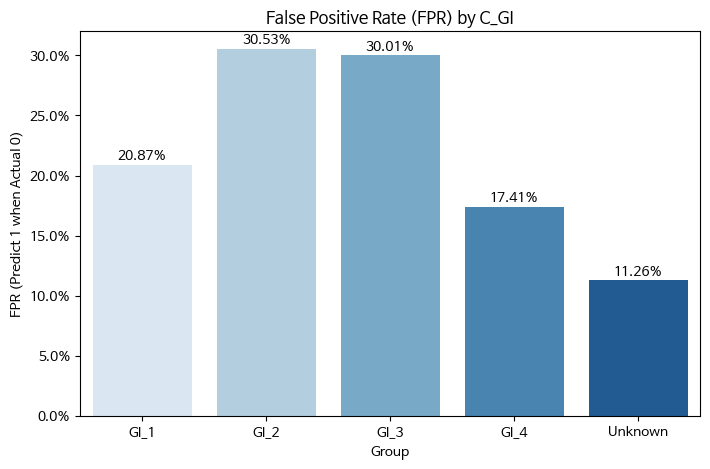

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.281900,28.19%,55.47%,20.87%,41.60%
1,GI_2,0.232200,0.377800,37.78%,61.75%,30.53%,37.95%
2,GI_3,0.209700,0.372600,37.26%,64.58%,30.01%,36.35%
3,GI_4,0.143700,0.218100,21.81%,48.07%,17.41%,31.67%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%



 [Step 3] Base Model (보정 전) 학습 결과


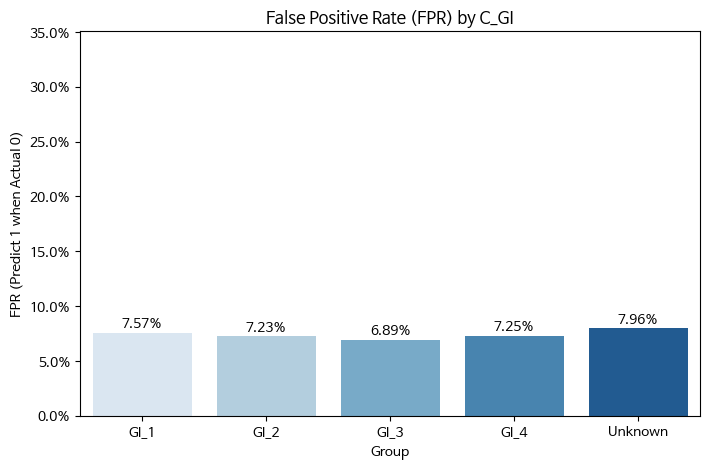

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.101700,10.17%,19.85%,7.57%,41.27%
1,GI_2,0.232200,0.121500,12.15%,28.44%,7.23%,54.33%
2,GI_3,0.209700,0.121700,12.17%,32.09%,6.89%,55.29%
3,GI_4,0.143700,0.103600,10.36%,28.93%,7.25%,40.12%
4,Unknown,0.115600,0.099200,9.92%,24.93%,7.96%,29.04%


In [ ]:
var_name = 'c_gi'
y_pred_final_5, thresholds_auto_5 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

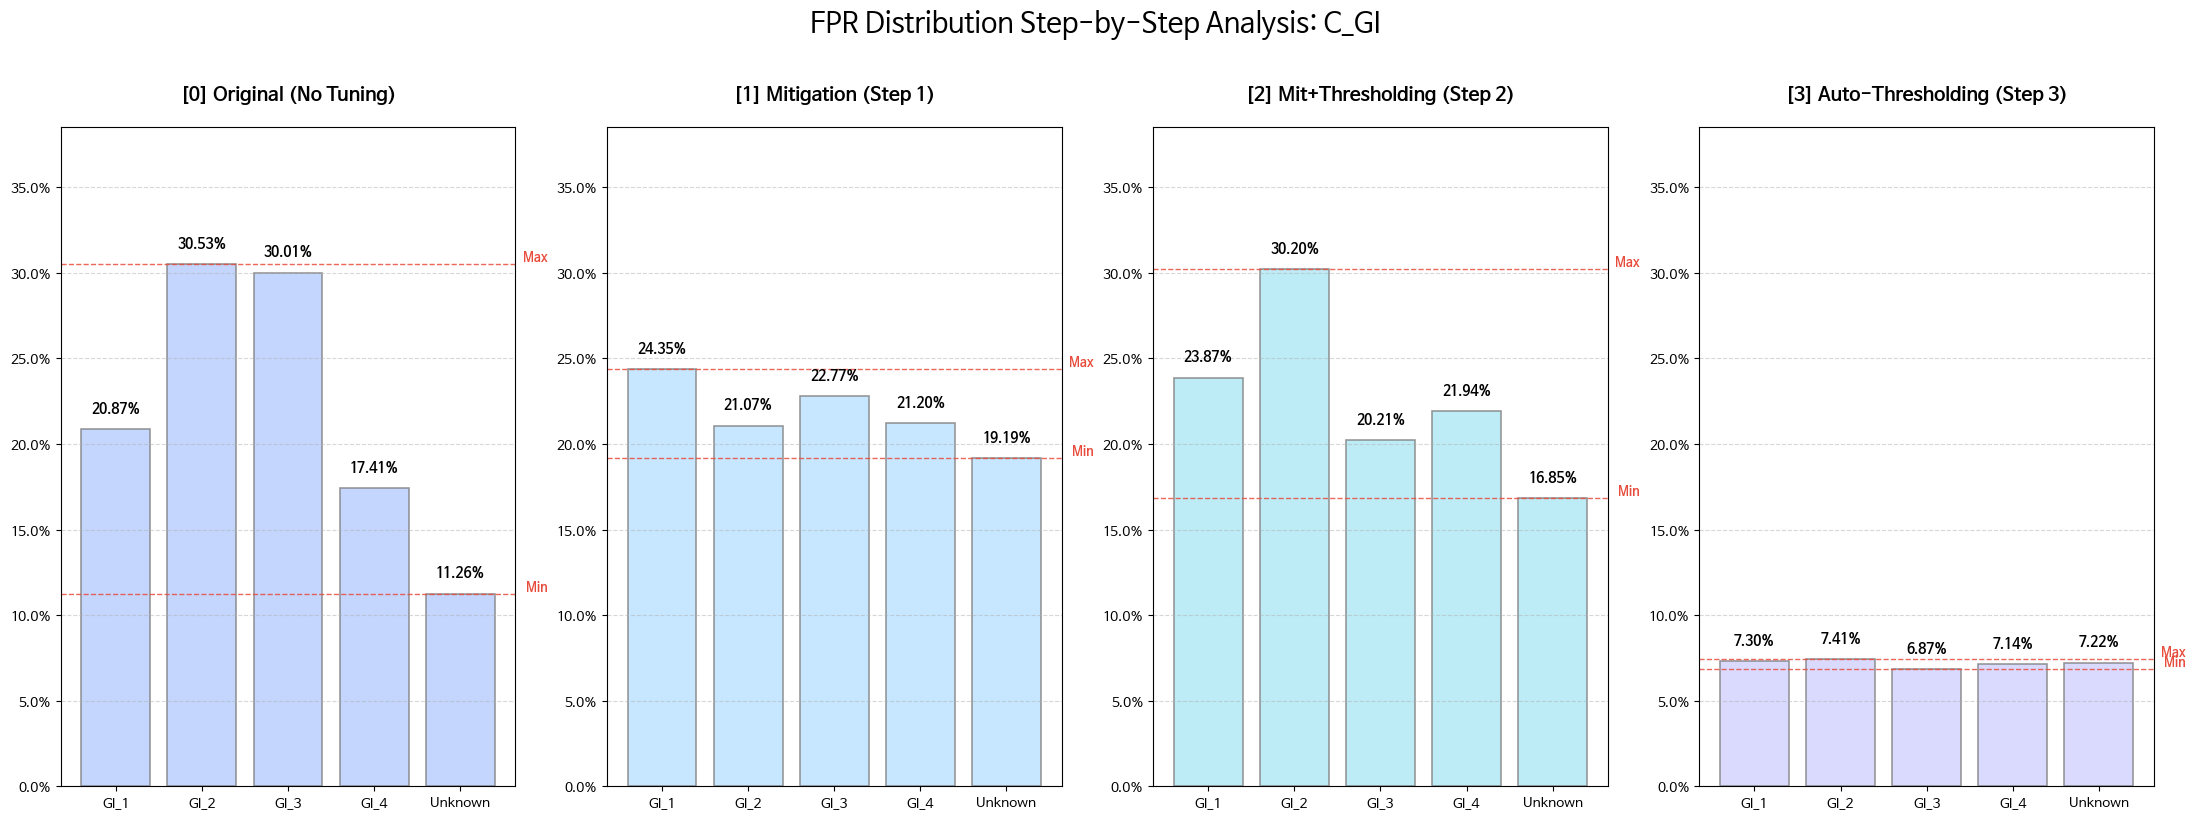

In [ ]:
y_preds = [y_pred_org, y_pred_mit_5, y_pred_post_5, y_pred_final_5]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive_5, y_pred_org, y_pred_mit_5, y_pred_post_5, y_pred_final_5, mitigator_5, thresholds_manual_5, thresholds_auto_5)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


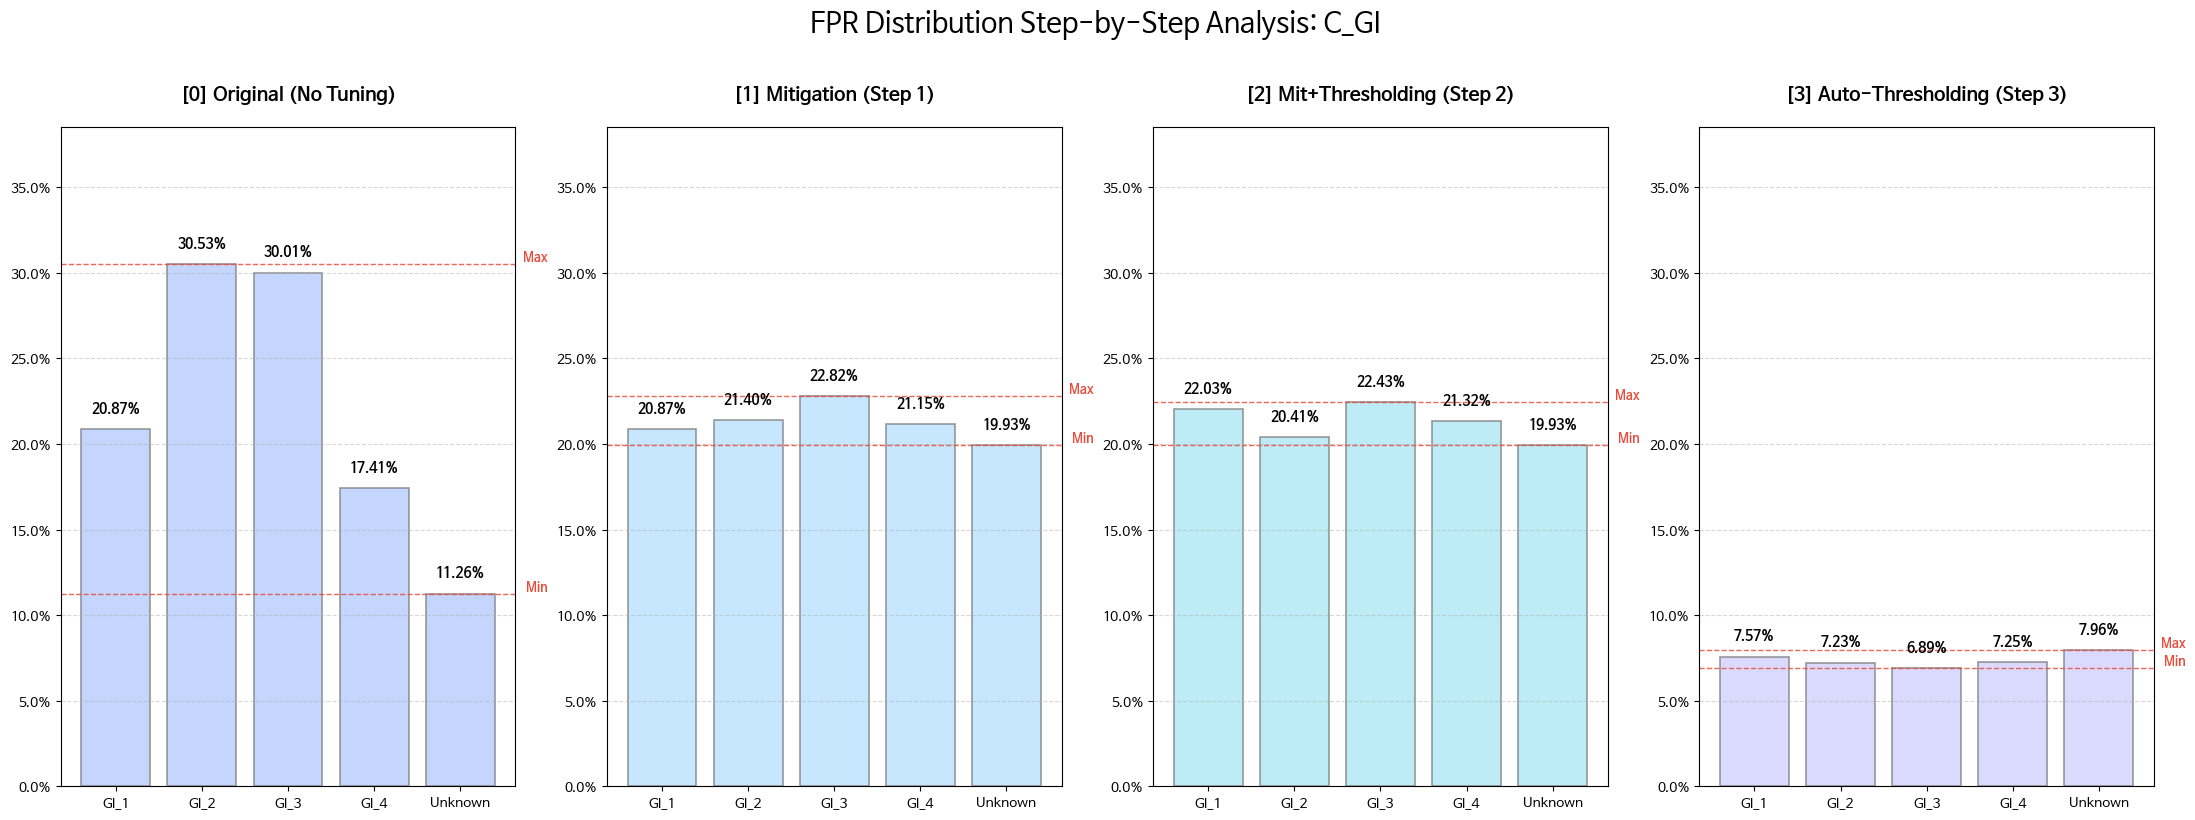

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

##### `C_IE_T`

 [Step 1] Base Model (보정 전) 학습 및 평가

       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.345920  0.597358  0.720618  0.279382  0.402642
C_IE_T_2        0.278553  0.557668  0.780263  0.219737  0.442332
C_IE_T_3        0.235851  0.504381  0.809512  0.190488  0.495619
C_IE_T_4        0.167919  0.419596  0.867987  0.132013  0.580404
Unknown         0.153292  0.464589  0.887407  0.112593  0.535411
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.192628
tpr               0.177762
tnr               0.166789
fpr               0.166789
fnr               0.177762
dtype: float64

 [Step 2] Fairlearn Mitigator (1차 보정) 학습

⚖️ Fairlearn 재학습 중...
       [Fairlearn 모델 1차 학습 성능 결과]        
F1-Score: 0.3943
PR-AUC: 0.3190
Recall: 

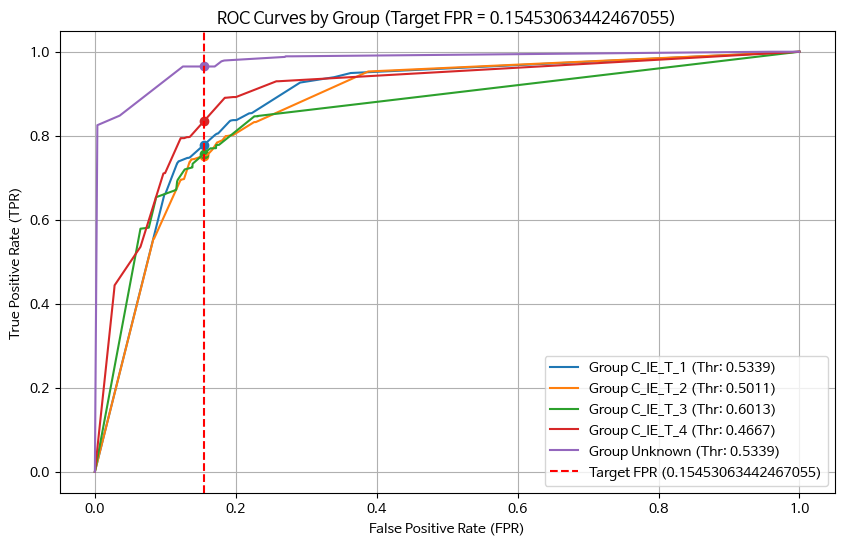

       [최종 모델 전체 성능 결과]        
F1-Score  : 0.4062
PR-AUC : 0.3190
Recall    : 0.5058
Precision : 0.3393

       [최종 - 집단별 임계값]       
Group C_IE_T_1: 0.5339
Group C_IE_T_2: 0.5011
Group C_IE_T_3: 0.6013
Group C_IE_T_4: 0.4667
Group Unknown: 0.5339

       [최종 - 연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.248010  0.489828  0.815983  0.184017  0.510172
C_IE_T_2        0.236089  0.509189  0.821460  0.178540  0.490811
C_IE_T_3        0.256441  0.527238  0.789304  0.210696  0.472762
C_IE_T_4        0.221351  0.493849  0.817526  0.182474  0.506151
Unknown         0.234851  0.563739  0.808148  0.191852  0.436261

       [최종 - 집단 간 최대 격차 (Max Gap)]      
selection_rate    0.035091
tpr               0.073911
tnr               0.032155
fpr               0.032155
fnr               0.073911
dtype: float64

 ✅ 모든 공정성 개선 파이프라인이 완료되었습니다.

 [Step 0] Base Model (보정 전) 학습 결과



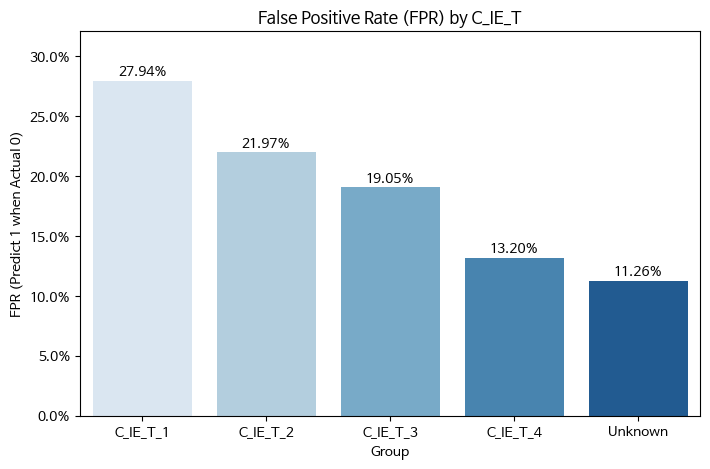

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.345900,34.59%,59.74%,27.94%,36.14%
1,C_IE_T_2,0.174000,0.278600,27.86%,55.77%,21.97%,34.84%
2,C_IE_T_3,0.144500,0.235900,23.59%,50.44%,19.05%,30.91%
3,C_IE_T_4,0.124900,0.167900,16.79%,41.96%,13.20%,31.20%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%



 [Step 1] Fairlearn Mitigator (1차 보정) 학습 결과



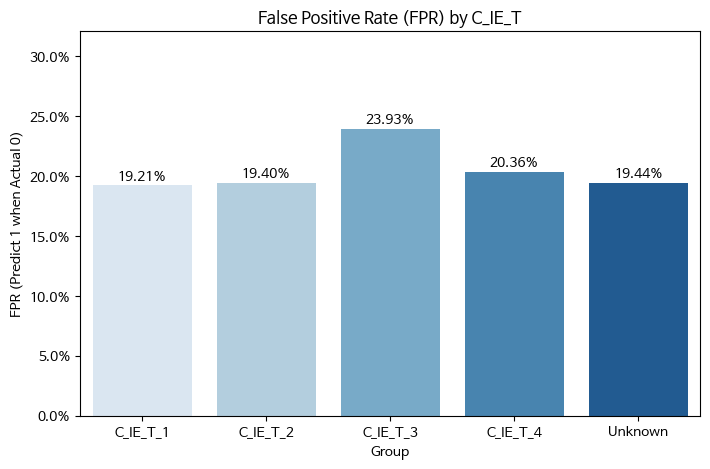

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.255200,25.52%,49.35%,19.21%,40.47%
1,C_IE_T_2,0.174000,0.250500,25.05%,51.84%,19.40%,36.02%
2,C_IE_T_3,0.144500,0.284000,28.40%,54.82%,23.93%,27.90%
3,C_IE_T_4,0.124900,0.240000,24.00%,49.52%,20.36%,25.76%
4,Unknown,0.115600,0.222100,22.21%,43.34%,19.44%,22.57%



 [Step 2] Post-processing (2차 임계값 튜닝) 결과



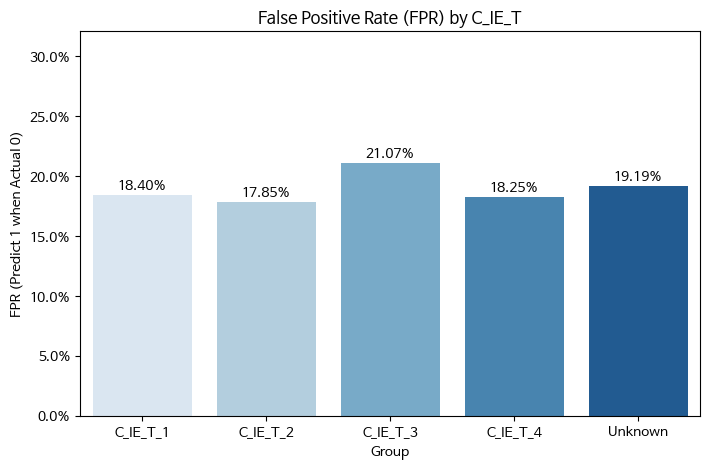

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.248000,24.80%,48.98%,18.40%,41.33%
1,C_IE_T_2,0.174000,0.236100,23.61%,50.92%,17.85%,37.54%
2,C_IE_T_3,0.144500,0.256400,25.64%,52.72%,21.07%,29.71%
3,C_IE_T_4,0.124900,0.221400,22.14%,49.38%,18.25%,27.86%
4,Unknown,0.115600,0.234900,23.49%,56.37%,19.19%,27.75%


In [ ]:
var_name = 'c_ie_t'
x_test_sensitive_6, y_pred_org, y_pred_mit_6, y_pred_post_6, mitigator_6, thresholds_manual_6 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )


       [공통 임계값]       
0.5024092

       [연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.345920  0.597358  0.720618  0.279382  0.402642
C_IE_T_2        0.278553  0.557668  0.780263  0.219737  0.442332
C_IE_T_3        0.235851  0.504381  0.809512  0.190488  0.495619
C_IE_T_4        0.167919  0.419596  0.867987  0.132013  0.580404
Unknown         0.153292  0.464589  0.887407  0.112593  0.535411
       [학습 전 결과]       
F1-Score  : 0.4128
PR-AUC : 0.3990
Recall    : 0.5301
Precision : 0.3381
공통 임계값: 0.5024092197418213

집단 간 최대 격차 (Max Gap)
selection_rate    0.192628
tpr               0.177762
tnr               0.166789
fpr               0.166789
fnr               0.177762
dtype: float64


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.0053198 0.0053198 0.0053198 ... 0.0053198 0.0053198 0.0053198]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[


       [최종 모델 전체 성능 결과]        
F1-Score  : 0.3071
PR-AUC : 0.2331
Recall    : 0.2258
Precision : 0.4798

       [집단별 임계값]       
연령대: C_IE_T_1 | 추정 임계값: 0.5041
연령대: C_IE_T_2 | 추정 임계값: 0.4814
연령대: C_IE_T_3 | 추정 임계값: 0.6522
연령대: C_IE_T_4 | 추정 임계값: 0.4809
연령대: Unknown | 추정 임계값: 0.5100

       [연령대별 공정성 세부 지표]       
          selection_rate       tpr       tnr       fpr       fnr
C_IE_T                                                          
C_IE_T_1        0.078063  0.210568  0.957002  0.042998  0.789432
C_IE_T_2        0.080626  0.249366  0.954931  0.045069  0.750634
C_IE_T_3        0.077791  0.250667  0.951413  0.048587  0.749333
C_IE_T_4        0.068956  0.200791  0.949853  0.050147  0.799209
Unknown         0.064199  0.155807  0.947778  0.052222  0.844193

       [집단 간 최대 격차 (Max Gap)]      
selection_rate    0.016427
tpr               0.094859
tnr               0.009224
fpr               0.009224
fnr               0.094859
dtype: float64

 [Step 0] Base Model (보정 전) 학습 결과


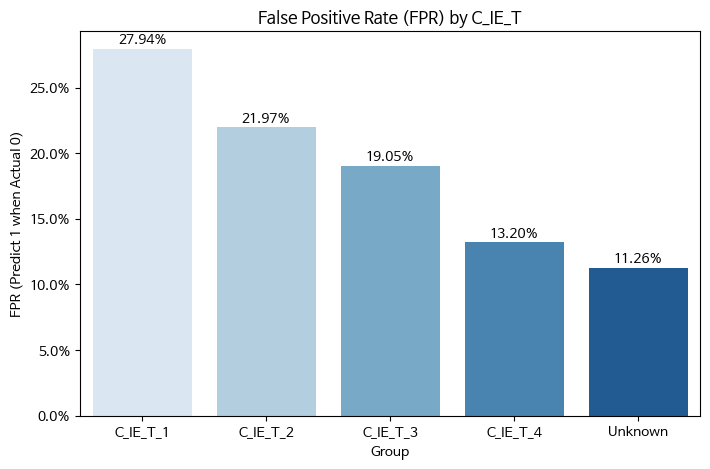

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.345900,34.59%,59.74%,27.94%,36.14%
1,C_IE_T_2,0.174000,0.278600,27.86%,55.77%,21.97%,34.84%
2,C_IE_T_3,0.144500,0.235900,23.59%,50.44%,19.05%,30.91%
3,C_IE_T_4,0.124900,0.167900,16.79%,41.96%,13.20%,31.20%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%



 [Step 3] Base Model (보정 전) 학습 결과


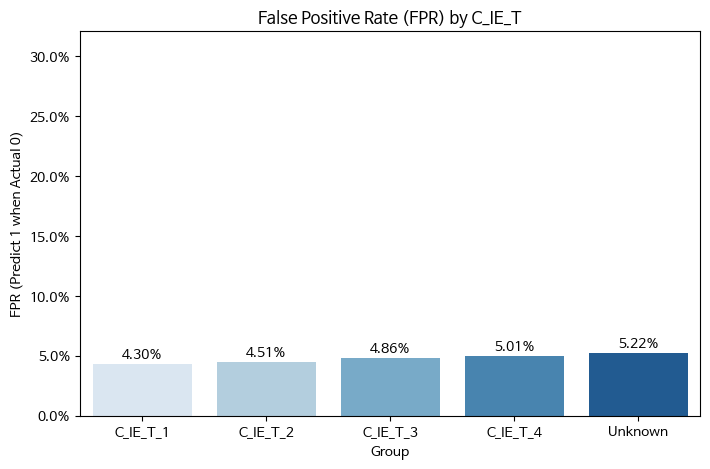

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.078100,7.81%,21.06%,4.30%,56.44%
1,C_IE_T_2,0.174000,0.080600,8.06%,24.94%,4.51%,53.83%
2,C_IE_T_3,0.144500,0.077800,7.78%,25.07%,4.86%,46.57%
3,C_IE_T_4,0.124900,0.069000,6.90%,20.08%,5.01%,36.36%
4,Unknown,0.115600,0.064200,6.42%,15.58%,5.22%,28.06%


In [ ]:
var_name = 'c_ie_t'
y_pred_final_6, thresholds_auto_6 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

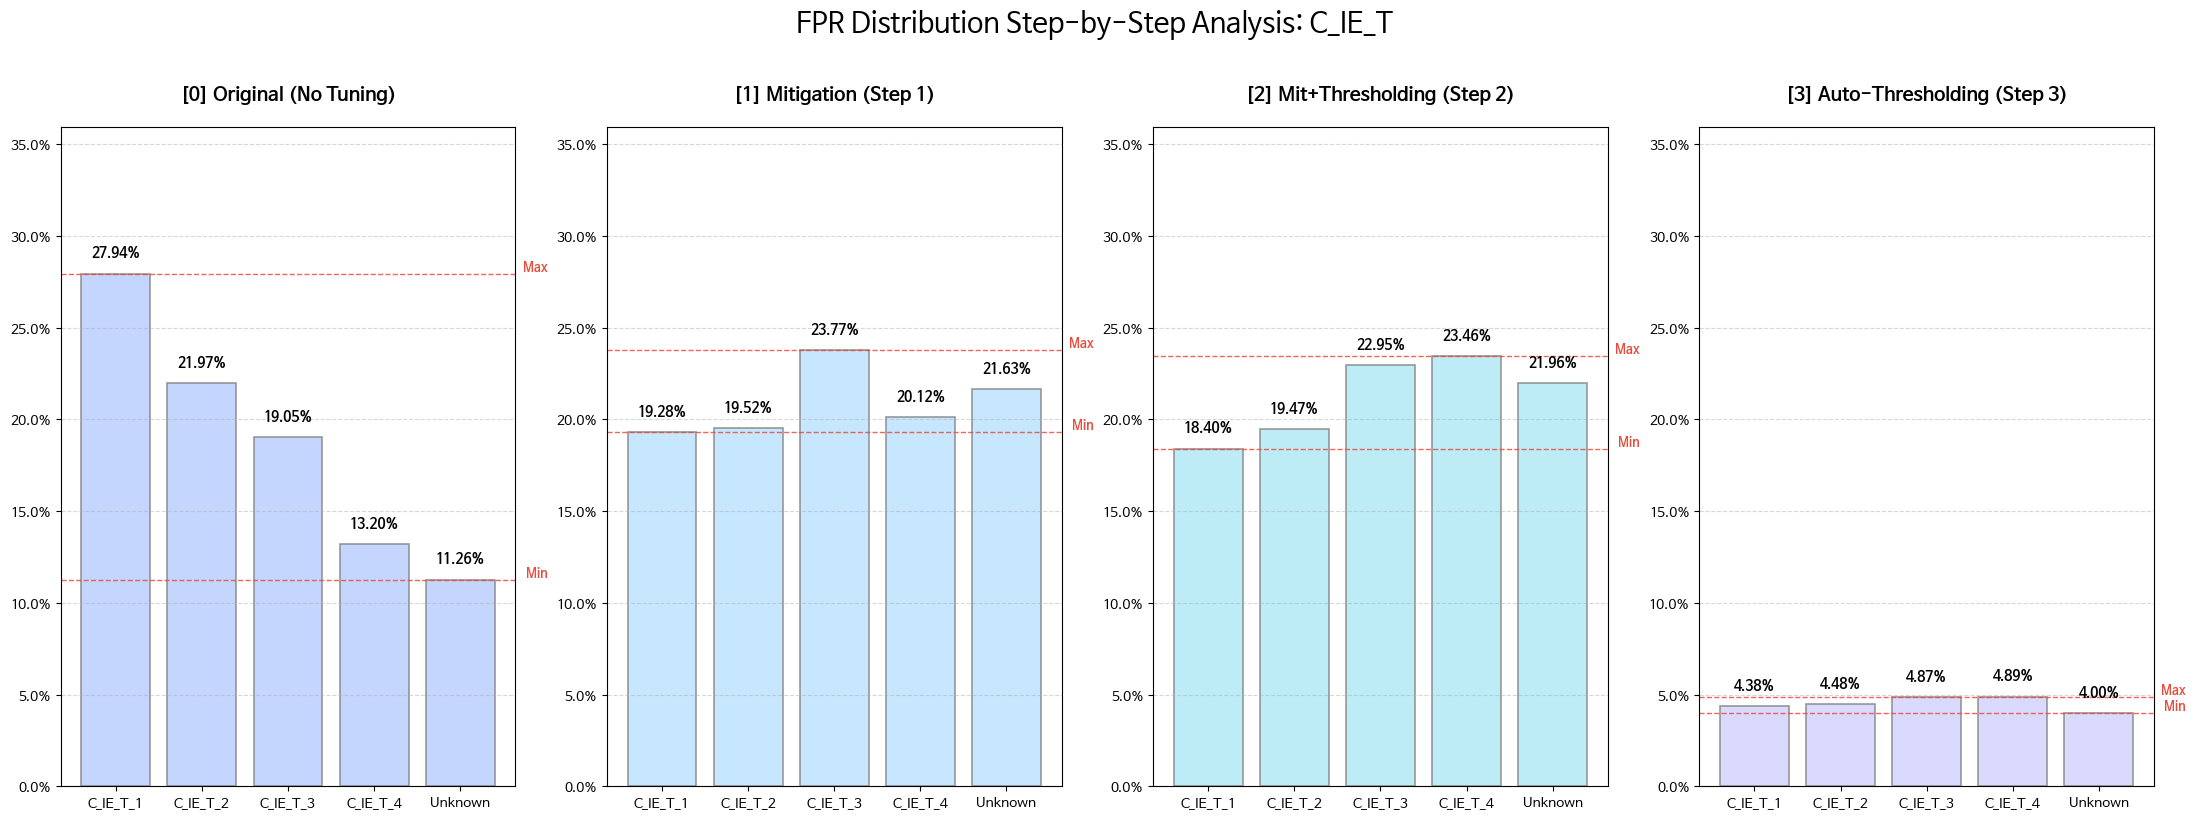

In [ ]:
y_preds = [y_pred_org, y_pred_mit_6, y_pred_post_6, y_pred_final_6]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

In [ ]:
save_data(var_name, x_test_sensitive_6, y_pred_org, y_pred_mit_6, y_pred_post_6, y_pred_final_6, mitigator_6, thresholds_manual_6, thresholds_auto_6)

✅ 검정용 예측값 데이터프레임 저장 완료!
✅ 모델 패키지 저장 완료!


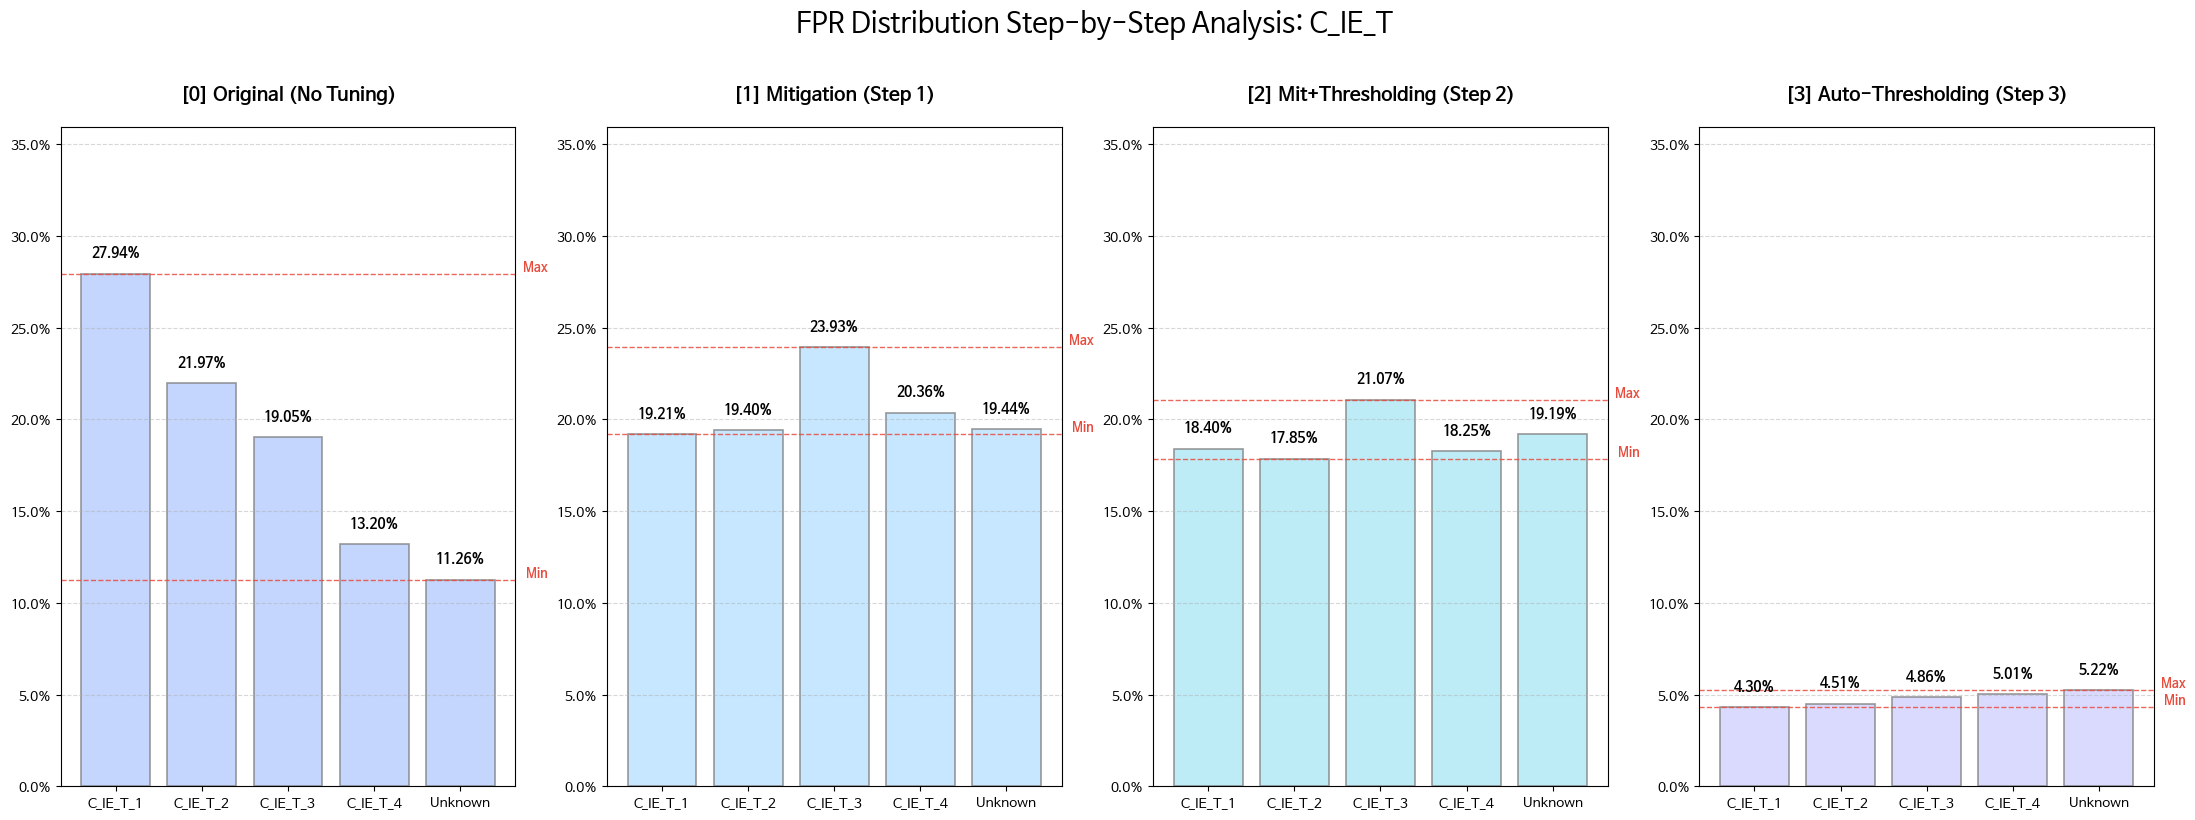

In [ ]:
save_path = f"Tuning_Results/{var_name}"
fairness_data = pd.read_csv(f"{save_path}/fairness_summary.csv")
x_test_sensitive = fairness_data['sensitive_group']
y_test = fairness_data['y_true']
y_pred_org, y_pred_mit, y_pred_post, y_pred_final = fairness_data['y_pred_org'], fairness_data['y_pred_mit'], fairness_data['y_pred_post'], fairness_data['y_pred_final']
y_preds = [y_pred_org, y_pred_mit, y_pred_post, y_pred_final]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)

#### 최종 그래프 - age_gender

In [ ]:
var_name = 'age_gender'
x_test_sensitive, y_pred_org, y_pred_mit_3, y_pred_post_3 = fairlearn_run_all(
        var_name, variable_map,
        x_train, y_train, x_val, y_val, x_test, y_test,
        best_params, fixed_params, threshold
        )

var_name = 'age_gender'
y_pred_final_3 = fairlearn_run_thr(model, threshold, var_name, x_train, y_train, x_val, y_val, x_test, y_test)

y_pred_idx_1 = y_pred_final_3
y_pred_idx_2 = # 예린
y_pred_idx_3 = y_pred_post_3

y_preds = [y_pred_org, y_pred_mit_3, y_pred_post_3, y_pred_final_3]
plot_combined_fpr(var_name, y_test, y_preds, x_test_sensitive)